### Install required packages

In [3]:
# Uncomment and replace with the path of your venv or pip (if global) - also replace jax[cuda12] with jax[cuda12-local] to use a local already installed CUDA or with jax[cpu] if no GPU is available.
!pip install numpy pandas tqdm matplotlib scikit-learn jax[cuda12] seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.5/40.5 MB 18.1 MB/s eta 0:00:00
  Attempting uninstall: nvidia-cuda-nvcc-cu12
    Found existing installation: nvidia-cuda-nvcc-cu12 12.5.82
    Uninstalling nvidia-cuda-nvcc-cu12-12.5.82:
      Successfully uninstalled nvidia-cuda-nvcc-cu12-12.5.82


# Import the required libraries

In [1]:
import os
import urllib.request
import zipfile
import zlib
import gzip
import shutil
import jax
import jax.numpy as jnp
import numpy as np
import pandas as pd
from jax import lax
from tqdm import tqdm
from tqdm.auto import trange
import matplotlib.pyplot as plt
import time
import json
from typing import Optional

# Data Loading
Download and load the datasets

In [2]:


def download_movielens_100k(data_dir="ml-100k"):
    """
    Downloads and extracts MovieLens 100k dataset.

    Args:
        data_dir: Directory to store the dataset

    Returns:
        str: Path to the extracted dataset directory
    """
    if os.path.exists(os.path.join(data_dir, "u.data")):
        print("MovieLens 100k dataset found.")
        return data_dir

    print("Downloading MovieLens 100k dataset...")
    url = "http://files.grouplens.org/datasets/movielens/ml-100k.zip"
    zip_path = "ml-100k.zip"
    urllib.request.urlretrieve(url, zip_path)

    print("Extracting dataset...")
    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(".")
    os.remove(zip_path)
    print(f"Dataset extracted to {data_dir}")
    return data_dir


def load_movielens_100k(test_ratio=0.1, val_ratio=0.2, random_state=42):
    """
    Load MovieLens 100k dataset and split into train/validation/test sets.

    Args:
        test_ratio: Fraction of data for test set
        val_ratio: Fraction of data for validation set
        random_state: Random seed for reproducibility

    Returns:
        tuple: (user_item_matrix, mask_train, mask_val, mask_test)
    """
    download_movielens_100k()
    df = pd.read_csv(
        "ml-100k/u.data",
        sep="\t",
        names=["user_id", "movie_id", "rating", "timestamp"],
    )
    user_item_matrix = df.pivot_table(index="user_id", columns="movie_id", values="rating", fill_value=0)
    user_item_matrix = np.array(user_item_matrix)
    mask_train, mask_val, mask_test = train_val_test_split(
        user_item_matrix, test_size=test_ratio, val_size=val_ratio, random_state=random_state
    )

    return jnp.array(user_item_matrix), mask_train, mask_val, mask_test


def download_amazon_office(data_dir="amazon_office"):
    """
    Downloads and extracts Amazon Office dataset.

    Args:
        data_dir: Directory to store the dataset

    Returns:
        str: Path to the extracted dataset directory
    """
    # Create data directory if it doesn't exist
    if not os.path.exists(data_dir):
        os.makedirs(data_dir)

    gzip_path = os.path.join(data_dir, "Office_Products_5.json.gz")
    file_name = "Office_Products_5.json"

    if os.path.exists(os.path.join(data_dir, file_name)):
        print("Amazon Office dataset found.")
        return data_dir
    print("Downloading Amazon Office dataset...")
    urllib.request.urlretrieve("http://snap.stanford.edu/data/amazon/productGraph/categoryFiles/reviews_Office_Products_5.json.gz", gzip_path)

    print("Extracting dataset...")
    with gzip.open(gzip_path, 'rb') as f_in:
        with open(os.path.join(data_dir, file_name), 'wb') as f_out:
            shutil.copyfileobj(f_in, f_out)
    os.remove(gzip_path)
    print(f"Dataset extracted to {data_dir}")
    return data_dir

def load_amazon_office(test_ratio=0.1, val_ratio=0.2, random_state=42):
    """
    Load Amazon Office dataset and split into train/validation/test sets.

    Args:
        test_ratio: Fraction of data for test set
        val_ratio: Fraction of data for validation set
        random_state: Random seed for reproducibility

    Returns:
        tuple: (user_item_matrix, mask_train, mask_val, mask_test)
    """
    download_amazon_office()
    with open('amazon_office/Office_Products_5.json', 'r') as f:
        data = [json.loads(line) for line in f]  # Load line-by-line JSON (Amazon format)

    df = pd.DataFrame(data)  # Convert to pandas dataframe

    # Create user-item matrix: rows = users, columns = items
    user_item_matrix = df.pivot_table(index='reviewerID',
                                     columns='asin',
                                     values='overall',
                                     fill_value=0)

    # Select a subset of the data for computational efficiency
    user_item_matrix = user_item_matrix.iloc[:1000, :1600]

    mask_train, mask_val, mask_test = train_val_test_split(
        user_item_matrix, test_size=test_ratio, val_size=val_ratio, random_state=random_state
    )

    return jnp.array(user_item_matrix), mask_train, mask_val, mask_test

def download_sweetrs_dataset(data_dir="sweetrs_data"):
    """Downloads the SweetRS dataset from the provided URL."""
    if not os.path.exists(data_dir):
        os.makedirs(data_dir)

    file_path = os.path.join(data_dir, "ratings-final.csv")

    if os.path.exists(file_path):
        print("SweetRS dataset found.")
        return data_dir

    print("Downloading SweetRS dataset...")
    url = "https://raw.githubusercontent.com/kidzik/sweetrs-analysis/refs/heads/master/ratings-final.csv"

    try:
        urllib.request.urlretrieve(url, file_path)
        print(f"Dataset downloaded to {file_path}")
    except Exception as e:
        print(f"Error downloading dataset: {e}")
        return None

    return data_dir

def load_sweetrs_dataset(test_ratio=0.1, val_ratio=0.2, random_state=42):
    """
    Loads SweetRS dataset and splits it into train, validation, and test sets.
    """
    # Download dataset if not already present
    data_dir = download_sweetrs_dataset()
    if data_dir is None:
        raise FileNotFoundError("Failed to download SweetRS dataset")

    # Load the CSV file
    file_path = os.path.join(data_dir, "ratings-final.csv")
    df = pd.read_csv(file_path)

    # Verify the expected columns exist
    expected_columns = ["product", "user", "value"]
    if not all(col in df.columns for col in expected_columns):
        raise ValueError(f"Expected columns {expected_columns} not found in dataset")

    # Create user-item matrix
    user_item_matrix = df.pivot_table(
        index="user",
        columns="product",
        values="value",
        fill_value=0
    )

    # Convert to numpy array
    user_item_matrix = np.array(user_item_matrix)

    # Split into train/val/test sets
    mask_train, mask_val, mask_test = train_val_test_split(
        user_item_matrix,
        test_size=test_ratio,
        val_size=val_ratio,
        random_state=random_state
    )

    return jnp.array(user_item_matrix), mask_train, mask_val, mask_test


def train_val_test_split(
    Y,
    test_size: float = 0.10,
    val_size: float = 0.20,
    random_state: Optional[int] = None,
):
    """
    Split a user–item rating matrix Y into train/validation/test sets.

    Parameters
    ----------
    Y : array_like, shape (n_users, n_items)
        User–item rating matrix (0 = missing).
    test_size : float, default=0.10
        Fraction of nonzero entries to assign to test set.
    val_size : float, default=0.20
        Fraction of nonzero entries to assign to validation set.
    random_state : int or None
        Seed for reproducibility.
    Returns
    -------
        train_mask, val_mask, test_mask : jnp.ndarray of bool
            Three masks you can apply to Y: Y*train_mask etc.
    """
    if not (0 <= test_size < 1 and 0 <= val_size < 1 and test_size + val_size < 1):
        raise ValueError("Require 0 ≤ test_size+val_size < 1")

    if random_state is not None:
        np.random.seed(random_state)

    # 1) Find nonzero entries
    nz = np.argwhere(Y != 0)
    n_nz = len(nz)

    # 2) Shuffle indices
    perm = np.random.permutation(n_nz)  # Return a random permutation of length len(nz)

    # 3) Compute split counts
    n_test = int(n_nz * test_size)
    n_val = int(n_nz * val_size)
    # Rest goes to train

    # 4) Assign splits
    test_idx = perm[:n_test]
    val_idx = perm[n_test : n_test + n_val]
    train_idx = perm[n_test + n_val :]

    test_coords = nz[test_idx]
    val_coords = nz[val_idx]
    train_coords = nz[train_idx]

    # 5) Build masks
    train_mask = np.zeros_like(Y, dtype=bool)
    val_mask = np.zeros_like(Y, dtype=bool)
    test_mask = np.zeros_like(Y, dtype=bool)

    train_mask[train_coords[:,0], train_coords[:,1]] = 1
    val_mask[val_coords[:,0], val_coords[:,1]] = 1
    test_mask[test_coords[:,0], test_coords[:,1]] = 1

    # Convert to JAX arrays
    train_mask = jnp.array(train_mask)
    val_mask = jnp.array(val_mask)
    test_mask = jnp.array(test_mask)

    return train_mask, val_mask, test_mask

# Plotting


In [3]:
def plot_history(
        train_history,
        train_rmse_history,
        test_rmse_history,
        gap_history,
        train_history_max_y=None,
        scale="linear",
):
    """
    Plot training history including objective function, RMSE, and Frank-Wolfe gap.

    Args:
        train_history: List of training objective values
        train_rmse_history: List of training RMSE values
        test_rmse_history: List of test/validation RMSE values
        gap_history: List of Frank-Wolfe gap values
        train_history_max_y: Optional max y-value for training objective plot
        scale: Scale for y-axis ("linear" or "log")
    """
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(14, 12))
    fig.suptitle("Optimization History", fontsize=16)

    # Plot training objective
    ax1.plot(train_history, linestyle="-", color="skyblue", linewidth=2)
    ax1.set_title("Training Objective Function", fontsize=14)
    ax1.set_xlabel("Iteration", fontsize=12)
    ax1.set_ylabel("Objective Function Value", fontsize=12)
    ax1.set_yscale(scale)
    ax1.grid(True, linestyle="--", alpha=0.7)
    if train_history_max_y is not None:
        ax1.set_ylim(top=train_history_max_y)

    # Plot training and test RMSE on the same plot (ax2)
    ax2.plot(
        train_rmse_history,
        linestyle="-",
        color="lightcoral",
        linewidth=2,
        label="Training RMSE",
    )
    ax2.plot(
        test_rmse_history,
        linestyle="-",
        color="mediumseagreen",
        linewidth=2,
        label="Test RMSE",
    )
    ax2.set_title("Training and Test RMSE", fontsize=14)
    ax2.set_xlabel("Iteration", fontsize=12)
    ax2.set_ylabel("RMSE Value", fontsize=12)
    ax2.set_yscale(scale)
    ax2.grid(True, linestyle="--", alpha=0.7)
    ax2.legend(fontsize=10)  # Add legend to differentiate lines

    # ax3 is now empty as RMSE plots are merged into ax2. Can be used for something else or removed.
    # For now, hide this subplot
    ax3.axis('off')  # Hide this subplot

    # Plot FW Gap
    ax4.plot(gap_history, linestyle="-", color="orchid", linewidth=2)
    ax4.set_title("FW Gap", fontsize=14)
    ax4.set_xlabel("Iteration", fontsize=12)
    ax4.set_ylabel("Gap Value", fontsize=12)
    ax4.set_yscale(scale)
    ax4.grid(True, linestyle="--", alpha=0.7)

    plt.tight_layout(rect=[0, 0.03, 1, 0.96])  # Adjust layout to prevent title overlap
    plt.show()

def generate_pipeline_plots(results, prefix=""):
    """
    Generates plots for Test RMSE vs. Iterations and a bar chart for Wall Time.

    Args:
        results: Dictionary containing algorithm results with 'test_rmse_history' and 'wall_time'
        prefix: Prefix for saved plot filenames
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle("Algorithm Performance Comparison", fontsize=16)

    # Plot 1: Test RMSE vs. Iterations
    ax1.plot(
        results["fw"]["test_rmse_history"], label="FW", color="blue", linewidth=2
    )
    ax1.plot(
        results["pfw"]["test_rmse_history"],
        label="PFW (Hash)",
        color="green",
        linewidth=2,
    )
    ax1.plot(
        results["pgd"]["test_rmse_history"], label="PGD", color="red", linewidth=2
    )
    ax1.set_title("Test RMSE vs. Iterations")
    ax1.set_xlabel("Iteration")
    ax1.set_ylabel("Test RMSE")
    ax1.legend()
    ax1.grid(True, linestyle="--", alpha=0.6)
    ax1.set_ylim(bottom=0.9)  # Adjust as needed

    # Plot 2: Wall Time Comparison
    algorithms = list(results.keys())
    wall_times = [results[algo]["wall_time"] for algo in algorithms]
    colors = ["blue", "green", "red"]

    ax2.bar(algorithms, wall_times, color=colors)
    ax2.set_title("Wall-Clock Time for Final Run")
    ax2.set_xlabel("Algorithm")
    ax2.set_ylabel("Time (seconds)")
    ax2.grid(True, axis="y", linestyle="--", alpha=0.6)

    for i, v in enumerate(wall_times):
        ax2.text(i, v + 0.5, f"{v:.2f}s", ha="center", va="bottom")

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig(f"{prefix}_final")
    plt.show()

def plot_algorithm_metrics(metrics: tuple, algorithm_name: str, prefix=""):
    """
    Plots the training loss, train/validation RMSE, and FW gap over iterations
    for a given algorithm.

    Args:
        metrics: A tuple containing the history of metrics.
                 Expected format:
                 (train_loss_hist, train_rmse_hist, val_rmse_hist,
                  step_hist (optional), gap_hist (optional))
        algorithm_name: The name of the algorithm (e.g., 'FW', 'PFW', 'PGD').
        prefix: Prefix for saved plot filenames.
    """
    train_loss_hist = metrics[0]
    train_rmse_hist = metrics[1]
    val_rmse_hist = metrics[2]

    # Check if step_hist and gap_hist are present (e.g., for FW/PFW)
    step_hist = None
    gap_hist = None
    if len(metrics) > 3:
        step_hist = metrics[3]  # This would be step_hist
    if len(metrics) > 4:
        gap_hist = metrics[4]  # This would be gap_hist

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle(f"{algorithm_name} Optimization History", fontsize=16)

    # Plot 1: Training Objective Function
    axes[0].plot(
        train_loss_hist, linestyle="-", color="skyblue", linewidth=2
    )
    axes[0].set_title("Training Objective Function", fontsize=14)
    axes[0].set_xlabel("Iteration", fontsize=12)
    axes[0].set_ylabel("Objective Value", fontsize=12)
    axes[0].grid(True, linestyle="--", alpha=0.7)

    # Plot 2: Training and Validation RMSE
    axes[1].plot(
        train_rmse_hist,
        linestyle="-",
        color="lightcoral",
        linewidth=2,
        label="Training RMSE",
    )
    axes[1].plot(
        val_rmse_hist,
        linestyle="-",
        color="mediumseagreen",
        linewidth=2,
        label="Validation RMSE",
    )
    axes[1].set_title("Training and Validation RMSE", fontsize=14)
    axes[1].set_xlabel("Iteration", fontsize=12)
    axes[1].set_ylabel("RMSE Value", fontsize=12)
    axes[1].legend(fontsize=10)
    axes[1].grid(True, linestyle="--", alpha=0.7)

    # Plot 3: FW Gap (if available) or Placeholder
    if gap_hist is not None:
        axes[2].plot(gap_hist, linestyle="-", color="orchid", linewidth=2)
        axes[2].set_title("Frank-Wolfe Gap", fontsize=14)
        axes[2].set_xlabel("Iteration", fontsize=12)
        axes[2].set_ylabel("Gap Value", fontsize=12)
        axes[2].set_yscale("log")  # Gap is often plotted on log scale
        axes[2].grid(True, linestyle="--", alpha=0.7)
    else:
        axes[2].axis("off")  # Hide the subplot if no gap data
        axes[2].set_title("FW Gap (N/A for PGD)")

    plt.tight_layout(rect=[0, 0.03, 1, 0.96])
    plt.savefig(f"{prefix}_{algorithm_name}_metrics")
    plt.show()


def plot_gap_comparison(fw_gap_hist: list, pfw_gap_hist: list, prefix=""):
    """
    Plots the Frank-Wolfe gap for FW and PFW on a single graph for comparison.

    Args:
        fw_gap_hist: List of FW gap values over iterations.
        pfw_gap_hist: List of PFW gap values over iterations.
        prefix: Prefix for saved plot filenames.
    """
    plt.figure(figsize=(10, 6))
    plt.plot(
        fw_gap_hist,
        label="FW Gap",
        color="blue",
        linestyle="-",
        linewidth=2,
    )
    plt.plot(
        pfw_gap_hist,
        label="PFW (Hash) Gap",
        color="green",
        linestyle="--",
        linewidth=2,
    )
    plt.title("Frank-Wolfe Gap Comparison", fontsize=14)
    plt.xlabel("Iteration", fontsize=12)
    plt.ylabel("Gap Value", fontsize=12)
    plt.yscale("log")  # Log scale is typical for gap convergence
    plt.legend(fontsize=10)
    plt.grid(True, linestyle="--", alpha=0.7)
    plt.tight_layout()
    plt.savefig(f"{prefix}_gap_comparison.png")
    plt.show()

def plot_algo_performance(data):
    """
    Plots the performance (RMSE), matrix rank, and wall time for different algorithms
    across various datasets, with each metric on a single plot.

    Args:
        data: A dictionary where keys are dataset names and values are
              dictionaries containing algorithm results. Each algorithm result
              should have 'test_rmse', 'rank', and 'wall_time' keys.
    """

    metrics = ['test_rmse', 'rank', 'wall_time']
    titles = ['RMSE Performance per Algorithm and Dataset',
              'Matrix Rank per Algorithm and Dataset',
              'Wall Time per Algorithm and Dataset']
    ylabels = ['RMSE', 'Rank', 'Wall Time (seconds)']

    for i, metric in enumerate(metrics):
        plt.figure(figsize=(12, 7))  # Create a new figure for each metric
        ax = plt.gca()  # Get the current axes

        dataset_names = []
        algo_data = {}

        # Collect data for each algorithm and dataset
        for dataset_name, algos in data.items():
            dataset_names.append(dataset_name)
            for algo_name, algo_results in algos.items():
                if algo_name not in algo_data:
                    algo_data[algo_name] = []
                algo_data[algo_name].append(algo_results.get(metric))

        # Set up bar plot positions
        num_algos = len(algo_data)
        bar_width = 0.8 / num_algos  # Adjust bar width based on number of algorithms
        index = np.arange(len(dataset_names))

        # Plot bars for each algorithm
        for j, (algo_name, values) in enumerate(algo_data.items()):
            # Calculate the offset for each algorithm's bars
            offset = j * bar_width - (num_algos - 1) * bar_width / 2
            ax.bar(index + offset, values, bar_width, label=algo_name)

        ax.set_xlabel('Dataset Name', fontsize=12)
        ax.set_ylabel(ylabels[i], fontsize=12)
        ax.set_title(titles[i], fontsize=14)
        ax.set_xticks(index)
        ax.set_xticklabels(dataset_names, ha='right', fontsize=10)
        ax.legend(title="Algorithm", fontsize=10)
        ax.grid(axis='y', linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.savefig(f'algo_performance_{metric}.png')
        plt.show()

## Functions
Implement f(x), gradient, and rmse used in both FW and PGD.

In [4]:

@jax.jit
def objective_function(X, U, mask):
    return jnp.sum(jnp.square((X - U) * mask))


@jax.jit
def gradient_function(X, U, mask):
    return 2 * (X - U) * mask


@jax.jit
def rmse(X, U, mask):
    n = jnp.sum(mask)
    return jnp.sqrt(jnp.sum(jnp.square((X - U) * mask)) / n)


@jax.jit
def armijo_line_search(
        xk: jnp.ndarray,
        dk: jnp.ndarray,
        U: jnp.ndarray,
        mask: jnp.ndarray,
        gk: jnp.ndarray,
        alpha_max: float = 1.0,
        delta: float = 0.5,
        gamma: float = 1e-4,
        max_iter: int = 20,
) -> float:
    """
    Jittable Armijo backtracking. Finds
      alpha = delta^m * alpha_max
    such that
      f(xk + alpha dk) ≤ f(xk) + gamma * alpha * <gk, dk>.
    """
    # f(xk)
    f0 = objective_function(xk, U, mask)
    # directional derivative <gk, dk>
    inner = jnp.sum(gk * dk)

    # initialize m=0, alpha_0 = alpha_max, f(xk + alpha_0 dk)
    alpha0 = alpha_max
    f_alpha0 = objective_function(xk + alpha0 * dk, U, mask)
    init = (0, alpha0, f_alpha0)

    def cond_fun(carry):
        m, alpha_m, f_alpha_m = carry
        # continue if Armijo not satisfied and m < max_iter
        return jnp.logical_and(
            m < max_iter,
            f_alpha_m > f0 + gamma * alpha_m * inner,
        )

    def body_fun(carry):
        m, alpha_m, _ = carry
        alpha_next = alpha_m * delta
        f_next = objective_function(xk + alpha_next * dk, U, mask)
        return (m + 1, alpha_next, f_next)

    _, alpha_star, _ = lax.while_loop(cond_fun, body_fun, init)
    return alpha_star


# Functions
Implement f(x), gradient, and RMSE used in both FW and PGD.


In [5]:
@jax.jit
def objective_function(X, U, mask):
    """Compute the masked squared Frobenius norm objective function."""
    return jnp.sum(jnp.square((X - U) * mask))


@jax.jit
def gradient_function(X, U, mask):
    """Compute the gradient of the objective function with respect to X."""
    return 2 * (X - U) * mask


@jax.jit
def rmse(X, U, mask):
    """Compute the root mean squared error over the masked entries."""
    n = jnp.sum(mask)
    return jnp.sqrt(jnp.sum(jnp.square((X - U) * mask)) / n)

# Frank-Wolfe
Frank-Wolfe implementation, standard and pairwise, along with lmo and line search.

## Step-sizes

In [6]:

@jax.jit
def armijo_line_search(
        xk: jnp.ndarray,
        dk: jnp.ndarray,
        U: jnp.ndarray,
        mask: jnp.ndarray,
        gk: jnp.ndarray,
        alpha_max: float = 1.0,
        delta: float = 0.5,
        gamma: float = 1e-4,
        max_iter: int = 20,
) -> float:
    """
    Jittable Armijo backtracking line search. Finds
      alpha = delta^m * alpha_max
    such that
      f(xk + alpha dk) ≤ f(xk) + gamma * alpha * <gk, dk>.

    Args:
        xk: Current iterate
        dk: Search direction
        U: Data matrix
        mask: Observation mask
        gk: Gradient at current iterate
        alpha_max: Maximum step size
        delta: Backtracking factor (< 1)
        gamma: Armijo constant (small positive value)
        max_iter: Maximum number of backtracking steps

    Returns:
        float: Selected step size
    """
    # f(xk)
    f0 = objective_function(xk, U, mask)
    # Directional derivative <gk, dk>
    inner = jnp.sum(gk * dk)

    # Initialize m=0, alpha_0 = alpha_max, f(xk + alpha_0 dk)
    alpha0 = alpha_max
    f_alpha0 = objective_function(xk + alpha0 * dk, U, mask)
    init = (0, alpha0, f_alpha0)

    def cond_fun(carry):
        m, alpha_m, f_alpha_m = carry
        # Continue if Armijo not satisfied and m < max_iter
        return jnp.logical_and(
            m < max_iter,
            f_alpha_m > f0 + gamma * alpha_m * inner,
        )

    def body_fun(carry):
        m, alpha_m, _ = carry
        alpha_next = alpha_m * delta
        f_next = objective_function(xk + alpha_next * dk, U, mask)
        return (m + 1, alpha_next, f_next)

    _, alpha_star, _ = lax.while_loop(cond_fun, body_fun, init)
    return alpha_star


@jax.jit
def exact_line_search_closed_form(X, U, d, mask, max_step=1.0):
    """
    Compute the optimal step size in closed form:
      gamma = argmin_{gamma in [0,max_step]} ||(X + gamma*d - U)*mask||^2

    Args:
        X: Current iterate
        U: Data matrix
        d: Search direction
        mask: Observation mask
        max_step: Maximum allowed step size

    Returns:
        float: Optimal step size clipped to [0, max_step]
    """
    # Numerator = <U - X, d> over mask
    num = jnp.sum((U - X) * d * mask)
    # Denominator = ||d||^2 over mask
    den = jnp.sum(jnp.square(d) * mask)
    # Avoid division by zero and clip into [0, max_step]
    gamma = num / (den + 1e-16)
    return jnp.clip(gamma, 0.0, max_step)



## Required algorithms

Code required to run/optimize the algorithms but not part specifically of the FW.


In [7]:

# Used by LMO to approximate the top singular vectors of G
@jax.jit
def power_iteration_jit(G, tol=1e-4, key=None):
    """
    JIT-compatible power iteration to approximate the top singular vectors of G.

    Args:
        G: The input matrix (gradient).
        tol: Convergence tolerance for the power iteration.
        key: PRNGKey for random initialization.

    Returns:
        u1: Approximation of the left singular vector.
        v1: Approximation of the right singular vector.
    """
    # Initialize a random vector for the right singular vector
    if key is None:
        key = jax.random.PRNGKey(0)
    v = jax.random.normal(key, shape=(G.shape[1],))
    v = v / jnp.linalg.norm(v)

    def body_fn(carry):
        v, _ = carry
        # Compute the left singular vector approximation
        u = jnp.dot(G, v)
        u = u / jnp.linalg.norm(u)

        # Compute the right singular vector approximation
        v_new = jnp.dot(G.T, u)
        v_new = v_new / jnp.linalg.norm(v_new)

        # Compute the difference for convergence check
        diff = jnp.linalg.norm(v - v_new)
        return (v_new, diff)

    def cond_fn(carry):
        _, diff = carry
        return diff > tol

    # Run the power iteration loop
    v, _ = lax.while_loop(cond_fn, body_fn, (v, jnp.inf))
    u = jnp.dot(G, v)
    u = u / jnp.linalg.norm(u)

    return u, v


# Used by FW to hash the active set
def hash_crc32(x: jnp.ndarray, digits=4) -> int:
    """
    Compute a CRC32 hash of a JAX array for active set comparison.

    Args:
        x: JAX array to hash
        digits: Number of decimal places to round to before hashing

    Returns:
        int: CRC32 hash value
    """
    # View as bytes, and compute a checksum
    arr = np.asarray(x)
    arr_rounded = np.round(arr, decimals=digits)
    return zlib.crc32(arr_rounded.tobytes())

## FW and PFW implementations

In [8]:

# Original SVD-based LMO (commented out for reference):
# @jax.jit
# def lmo(G, delta):
#     u, _, vh = jnp.linalg.svd(-G, full_matrices=False)
#     u1 = u[:, 0]
#     vh1 = vh[0, :]
#     S = delta * jnp.outer(u1, vh1)
#     return S


@jax.jit
def lmo(G, delta, tol=1e-4, key=None):
    """
    JIT-compatible approximate LMO for the trace-norm ball using power iteration.

    Args:
        G: The gradient matrix.
        delta: The radius of the trace-norm ball.
        tol: Convergence tolerance for power iteration.
        key: PRNGKey for random initialization.

    Returns:
        S: The approximate solution to the LMO.
    """
    # Approximate the top singular vectors
    u1, v1 = power_iteration_jit(-G, tol=tol, key=key)

    # Construct the scaled rank-1 matrix
    S = delta * jnp.outer(u1, v1)
    return S


@jax.jit
def fw_step(x_k, U, mask_train, delta):
    """
    Perform one step of the Frank-Wolfe algorithm.

    Args:
        x_k: Current iterate
        U: Data matrix
        mask_train: Training mask
        delta: Constraint parameter for LMO

    Returns:
        tuple: (s_k, grad_k, fw_gap_k) where
            s_k is the FW vertex
            grad_k is the gradient at x_k
            fw_gap_k is the Frank-Wolfe gap
    """
    grad_k = gradient_function(x_k, U, mask_train)
    s_k = lmo(grad_k, delta)
    fw_gap_k = -jnp.vdot(grad_k, s_k - x_k)
    return s_k, grad_k, fw_gap_k

def fw(
        U,
        mask_train,
        mask_val,
        delta,
        num_iters,
        stepsize="exact",
        armijo_params={},
        patience=None,
):
    """
    Frank–Wolfe algorithm with switchable step sizes.

    Args:
        U: Data matrix
        mask_train: Training observation mask
        mask_val: Validation observation mask
        delta: Constraint parameter for trace norm ball
        num_iters: Maximum number of iterations
        stepsize: Step size strategy ("exact", "diminishing", or "armijo")
        armijo_params: Parameters for Armijo line search (if used)
        patience: Early stopping patience (None to disable)

    Returns:
        tuple: (best_x, best_val_rmse, history) where history contains
               (train_loss_hist, train_rmse_hist, val_rmse_hist, step_hist, gap_hist)
    """
    x_k = jnp.zeros_like(U)
    best_x = x_k.copy()
    best_val_rmse = float("inf")
    no_improve_counter = 0

    train_loss_hist, train_rmse_hist, val_rmse_hist, step_hist, gap_hist = (
        [],
        [],
        [],
        [],
        [],
    )

    @jax.jit
    def fw_update_step(k_inner, current_x_k):
        s_k, grad_k, fw_gap_k = fw_step(current_x_k, U, mask_train, delta)
        d_k = s_k - current_x_k

        if stepsize == "exact":
            alpha_k = exact_line_search_closed_form(
                current_x_k, U, d_k, mask_train
            )
        elif stepsize == "diminishing":
            alpha_k = 2.0 / (k_inner + 2.0)
        elif stepsize == "armijo":
            alpha_k = armijo_line_search(
                current_x_k, d_k, U, mask_train, grad_k, **armijo_params
            )
        else:
            raise ValueError(f"Unknown stepsize method '{stepsize}'")

        x_step = current_x_k + (alpha_k * d_k)

        return x_step, alpha_k, fw_gap_k

    pbar = trange(num_iters, desc="FW Progress")
    for k in pbar:
        x_k, gamma, gap = fw_update_step(k, x_k)

        if gap < 1e-5 and k > 0:
            print(f"FW Gap {gap:.4e} is very small. Stopping early.")
            break

        train_rmse_val = rmse(x_k, U, mask_train)
        val_rmse_val = rmse(x_k, U, mask_val)
        train_obj_val = objective_function(x_k, U, mask_train)

        train_rmse_hist.append(np.array(train_rmse_val))
        train_loss_hist.append(np.array(train_obj_val))
        val_rmse_hist.append(np.array(val_rmse_val))
        step_hist.append(gamma)
        gap_hist.append(gap)

        to_be_shown = {
            "Train RMSE": f"{train_rmse_val:.4f}",
            "Val RMSE": f"{val_rmse_val:.4f}",
            "Loss": f"{train_obj_val:.4f}",
            "Gap": f"{gap:.4f}",
            "StepSize": f"{gamma:.4f}",
        }

        if val_rmse_val < best_val_rmse:
            best_val_rmse = val_rmse_val
            best_x = x_k
            no_improve_counter = 0
        else:
            no_improve_counter += 1
            if patience is not None and no_improve_counter >= patience:
                print(
                    f"\nEarly stopping at iteration {k} "
                    f"(no improvement for {patience} steps)"
                )
                break

        pbar.set_postfix(to_be_shown)

        if (k == 0) or (k % 50 == 0):
            rank = jnp.linalg.matrix_rank(x_k)
            nuc = jnp.linalg.norm(x_k, ord="nuc")

            tqdm.write(
                f"[{k:3d}] Train RMSE: {train_rmse_val:.4f} | "
                f"Val RMSE: {val_rmse_val:.4f} | "
                f"Loss: {train_obj_val:.4f} | "
                f"Gap: {gap:.4f} | "
                f"StepSize: {gamma:.4f} | "
                f"Rank {rank}; Nuclear norm {nuc:.4f}"
            )

    return (best_x, best_val_rmse, (train_loss_hist, train_rmse_hist, val_rmse_hist, step_hist, gap_hist))


def fw_pairwise_hash(
        U: jax.Array,
        mask_train: jax.Array,
        mask_val: jax.Array,
        delta: float,
        num_iters: int,
        patience: Optional[int] = None,
        max_active_sets_size: int = 800,
):
    """
    Performs Pairwise Frank-Wolfe for matrix completion with hash-based active set management.

    This implementation uses a hash table to efficiently manage the active set of atoms,
    avoiding expensive linear searches when checking for duplicate vertices.

    Args:
        U: The full data matrix with missing entries set to 0.
        mask_train: A binary matrix where 1 indicates an observed training entry.
        mask_val: A binary matrix where 1 indicates an observed validation entry.
        delta: The hyperparameter for the LMO (trace norm ball radius).
        num_iters: The maximum number of iterations to run.
        patience: Early stopping patience (None to disable).
        max_active_sets_size: Maximum size of active set before pruning.

    Returns:
        A tuple containing:
        - The completed matrix with the best validation RMSE.
        - The best validation RMSE score.
        - History tuple: (train_loss_hist, train_rmse_hist, val_rmse_hist, step_hist, gap_hist)
    """

    # -- 1. Initialization --
    n, m = U.shape
    x_k = jnp.zeros((n, m))  # Start with a zero matrix
    best_x = x_k.copy()
    best_val_rmse = float("inf")
    no_improve_counter = 0

    active_set_atoms = [x_k]
    active_set_weights = [1.0]

    # Initialize hash bucket: checksum → list of indices into active_set_atoms
    bucket = {}
    h0 = hash_crc32(x_k)
    bucket.setdefault(h0, []).append(0)

    # The logs are saved as python arrays and not JAX to avoid cluttering the GPU
    train_loss_hist = []
    train_rmse_hist = []
    val_rmse_hist = []
    step_hist = []
    gap_hist = []

    print("Starting Pairwise Frank-Wolfe Optimization...")

    # Main PFW Loop
    pbar = trange(num_iters, desc="PFW Hash Progress")
    for k in pbar:
        # Calculate and store current performance
        train_loss = objective_function(x_k, U, mask_train)
        train_loss_hist.append(np.array(train_loss))

        train_rmse_val = rmse(x_k, U, mask_train)
        val_rmse_val = rmse(x_k, U, mask_val)
        train_rmse_hist.append(np.array(train_rmse_val))
        val_rmse_hist.append(np.array(val_rmse_val))

        # -- Compute Gradient and Find FW Vertex --
        s_k, grad_k, fw_gap_k = fw_step(x_k, U, mask_train, delta)

        # Calculate the Frank-Wolfe gap
        gap_hist.append(np.array(fw_gap_k))

        if fw_gap_k < 1e-4 and k > 0:
            print(f"FW Gap {fw_gap_k:.4e} is very small. Stopping early.")
            break

        # -- Find Away Vertex and PFW Direction --
        # Compute inner products
        inner_products = np.array(
           [jnp.vdot(grad_k, atom) for atom in active_set_atoms]
        )
        away_idx = int(np.argmax(inner_products))

        v_k = active_set_atoms[away_idx]
        d_k = s_k - v_k

        # Find Step Size
        alpha_max = active_set_weights[away_idx]
        alpha_k = exact_line_search_closed_form(
            x_k, U, d_k, mask_train, alpha_max
        )
        step_hist.append(float(alpha_k))

        # Update current value
        x_k = x_k + (alpha_k * d_k)

        # Validation and Early Stopping
        to_be_shown = {
            "Train RMSE": f"{train_rmse_val:.4f}",
            "Val RMSE": f"{val_rmse_val:.4f}",
            "Loss": f"{train_loss:.4f}",
            "Gap": f"{fw_gap_k:.4f}",
            "StepSize": f"{alpha_k:.4f}",
            "ActiveSetSize": f"{len(active_set_atoms)}",
        }

        if val_rmse_val < best_val_rmse:
            best_val_rmse = val_rmse_val
            best_x = x_k
            no_improve_counter = 0
        else:
            no_improve_counter += 1
            if patience is not None and no_improve_counter >= patience:
                print(
                    f"\nEarly stopping at iteration {k} "
                    f"(no improvement for {patience} steps)"
                )
                break
        pbar.set_postfix(to_be_shown)

        if (k == 0) or (k % 50 == 0):
            pfw_gap_k = -jnp.vdot(grad_k, s_k - v_k)
            rank = jnp.linalg.matrix_rank(x_k)
            nuc = jnp.linalg.norm(x_k, ord="nuc")
            tqdm.write(
                f"[{k:3d}] Train RMSE: {train_rmse_val:.4f} | "
                f"Val RMSE: {val_rmse_val:.4f} | Loss: {train_loss:.4f} | "
                f"Gap: {fw_gap_k:.4f} | PGap: {pfw_gap_k:.4f} | "
                f"StepSize: {alpha_k:.4f} (chosen), "
                f"{alpha_max:.4f} (max) | "
                f"ActiveSetSize: {len(active_set_atoms)} | "
                f"Rank {rank}; Nuclear norm {nuc:.4f}"
            )

        # -- Update Active Set and Weights --
        # 1) Reduce weight of the away atom
        active_set_weights[away_idx] -= alpha_k
        if active_set_weights[away_idx] <= 1e-12:
            # Remove zero-weight atom
            del active_set_atoms[away_idx]
            del active_set_weights[away_idx]
            # We skip pruning its index from bucket for efficiency

        # 2) Increase weight of the FW atom, using hash bucket
        h = hash_crc32(s_k)
        candidates = bucket.get(h, [])
        matched = False
        for idx in candidates:
            if bool(jnp.allclose(active_set_atoms[idx], s_k, atol=1e-4)):
                active_set_weights[idx] += alpha_k
                matched = True
                break

        if not matched:
            # Truly new atom
            new_idx = len(active_set_atoms)
            active_set_atoms.append(s_k)
            active_set_weights.append(alpha_k)
            bucket.setdefault(h, []).append(new_idx)

        # Prune active set if it gets too large
        if len(active_set_atoms) >= max_active_sets_size:
            atom_idx = np.argmin(active_set_weights)
            del active_set_atoms[atom_idx]
            del active_set_weights[atom_idx]

    print("...Optimization finished.")
    return (
        best_x,
        best_val_rmse,
        (train_loss_hist,
         train_rmse_hist,
         val_rmse_hist,
         step_hist,
         gap_hist,
         ))





# This is the original PFW implementation without any major optimizations
def fw_pairwise(
        U: jax.Array,
        mask_train: jax.Array,
        mask_val: jax.Array,
        delta: float,
        num_iters: int,
        patience: Optional[int] = None,
):
    """
    Performs Pairwise Frank-Wolfe for matrix completion (original implementation).

    This is the baseline implementation without hash-based optimizations,
    suitable for smaller problems or as a reference implementation.

    Args:
        U: The full data matrix with missing entries set to 0.
        mask_train: A binary matrix where 1 indicates an observed training entry.
        mask_val: A binary matrix where 1 indicates an observed validation entry.
        delta: The hyperparameter for the LMO (trace norm ball radius).
        num_iters: The maximum number of iterations to run.
        patience: Early stopping patience (None to disable).

    Returns:
        A tuple containing:
        - The completed matrix with the best validation RMSE.
        - The best validation RMSE score.
        - History tuple: (train_loss_hist, train_rmse_hist, val_rmse_hist, step_hist, gap_hist)
    """
    # -- 1. Initialization --
    n, m = U.shape
    x_k = jnp.zeros((n, m))  # Start with a zero matrix
    best_x = x_k.copy()
    best_val_rmse = float("inf")
    no_improve_counter = 0

    active_set_atoms = [x_k]
    active_set_weights = [1.0]

    # The logs are saved as python arrays and not JAX to avoid cluttering the GPU
    train_loss_hist, train_rmse_hist, val_rmse_hist, step_hist, gap_hist = (
        [],
        [],
        [],
        [],
        [],
    )

    print("Starting Pairwise Frank-Wolfe Optimization...")

    # Main PFW Loop
    pbar = trange(num_iters, desc="PFW Progress")
    for k in pbar:
        # Calculate and store current performance
        train_loss = objective_function(x_k, U, mask_train)
        train_loss_hist.append(np.array(train_loss))

        train_rmse_val = rmse(x_k, U, mask_train)
        val_rmse_val = rmse(x_k, U, mask_val)

        train_rmse_hist.append(np.array(train_rmse_val))
        val_rmse_hist.append(np.array(val_rmse_val))

        # -- Compute Gradient and Find FW Vertex --
        grad_k = gradient_function(x_k, U, mask_train)
        s_k = lmo(grad_k, delta)

        # Calculate the Frank-Wolfe gap
        fw_gap_k = -jnp.vdot(grad_k, s_k - x_k)
        gap_hist.append(np.array(fw_gap_k))

        if fw_gap_k < 1e-5 and k > 0:  # Gap too small
            print(f"FW Gap {fw_gap_k:.4e} is very small. Stopping early.")
            break

        # -- Find Away Vertex and PFW Direction --
        inner_products = jnp.array(
            [jnp.vdot(grad_k, atom) for atom in active_set_atoms]
        )

        away_idx = np.argmax(inner_products)
        v_k = active_set_atoms[away_idx]

        d_k = s_k - v_k

        # Find Step Size
        alpha_max = active_set_weights[away_idx]
        alpha_k = exact_line_search_closed_form(
            x_k, U, d_k, mask_train, alpha_max
        )
        step_hist.append(float(alpha_k))

        # Update current value
        x_k = x_k + (alpha_k * d_k)

        # Validation and Early Stopping
        to_be_shown = {
            "Train RMSE": f"{train_rmse_val:.4f}",
            "Val RMSE": f"{val_rmse_val:.4f}",
            "Loss": f"{train_loss:.4f}",
            "Gap": f"{fw_gap_k:.4f}",
            "StepSize": f"{alpha_k:.4f}",
            "ActiveSetSize": f"{len(active_set_atoms)}",
        }

        if val_rmse_val < best_val_rmse:
            best_val_rmse = val_rmse_val
            best_x = x_k
            no_improve_counter = 0
        else:
            no_improve_counter += 1
            if patience is not None and no_improve_counter >= patience:
                print(
                    f"\nEarly stopping at iteration {k} "
                    f"(no improvement for {patience} steps)"
                )
                break
        pbar.set_postfix(to_be_shown)

        if (k == 0) or (k % 50 == 0):
            # Compute rank and nuclear norm
            rank = jnp.linalg.matrix_rank(x_k)
            nuc = jnp.linalg.norm(x_k, ord="nuc")

            tqdm.write(
                f"[{k:3d}] Train RMSE: {train_rmse_val:.4f} | "
                f"Val RMSE: {val_rmse_val:.4f} | "
                f"Loss: {train_loss:.4f} | "
                f"Gap: {fw_gap_k:.4f} | "
                f"StepSize: {alpha_k:.4f} (chosen), {alpha_max:.4f} (max) | "
                f"ActiveSetSize: {len(active_set_atoms)} | "
                f"Rank {rank}; Nuclear norm {nuc:.4f}"
            )

        # Update Active Set and Weights
        active_set_weights[away_idx] -= alpha_k

        # Increase weight of the FW vertex. Check if it's already in the set.
        s_k_found_in_active_set = False

        for i, atom in enumerate(active_set_atoms):
            if jnp.allclose(atom, s_k, atol=1e-5):
                active_set_weights[i] += alpha_k
                s_k_found_in_active_set = True
                break

        # Add new atom if not found
        if not s_k_found_in_active_set:
            active_set_atoms.append(s_k)
            active_set_weights.append(alpha_k)

        # Remove atoms with essentially zero weight
        if alpha_max - alpha_k < 1e-5:
            del active_set_weights[away_idx]
            del active_set_atoms[away_idx]

    print("...Optimization finished.")
    return (best_x, best_val_rmse, (train_loss_hist, train_rmse_hist, val_rmse_hist, step_hist, gap_hist))


# Projected Gradient Descent

In [9]:

def project_to_rank(X, rank_k):
    """
    Project matrix X to rank-k matrices using SVD truncation.

    Args:
        X: Input matrix to project
        rank_k: Target rank

    Returns:
        Rank-k approximation of X
    """
    u, s, vh = jnp.linalg.svd(X, full_matrices=False)  # X is our trained low-rank matrix
    u_k = u[:, :rank_k]
    s_k = s[:rank_k]
    vh_k = vh[:rank_k, :]
    return u_k @ jnp.diag(s_k) @ vh_k


def pgd(
        U: jax.Array,
        mask_train: jax.Array,
        mask_val: jax.Array,
        num_iters: int,
        lr: float,
        k: int,
        patience: int = 100,
):
    """
    Performs Projected Gradient Descent for matrix completion.

    Args:
        U: The full data matrix with missing entries set to 0.
        mask_train: A binary matrix where 1 indicates an observed training entry.
        mask_val: A binary matrix where 1 indicates an observed validation entry.
        num_iters: The maximum number of iterations to run.
        lr: The learning rate for the gradient step.
        k: The rank for the projection step.
        patience: The number of iterations to wait for improvement before early stopping.

    Returns:
        A tuple containing:
        - The completed matrix with the best validation RMSE.
        - The best validation RMSE score.
        - A tuple with the history of (training loss, training RMSE, validation RMSE).
    """
    X = jnp.zeros_like(U)  # Start with a zero matrix
    best_val_rmse = float("inf")
    best_X = X
    no_improve_counter = 0

    train_loss_hist, train_rmse_hist, val_rmse_hist = [], [], []

    pbar = trange(num_iters, desc="PGD Progress")

    for i in pbar:
        # Perform one step of PGD
        grad = gradient_function(X, U, mask_train)
        # Gradient descent step
        updated_X = X - lr * grad
        # Projection step (SVD and rank-k truncation)
        X = project_to_rank(updated_X, k)

        # Calculate metrics for logging
        train_rmse_val = rmse(X, U, mask_train)
        train_obj_val = objective_function(X, U, mask_train)

        train_loss_hist.append(train_obj_val)
        train_rmse_hist.append(train_rmse_val)

        to_be_shown = {
            "Train RMSE": f"{train_rmse_val:.4f}",
            "Objective": f"{train_obj_val:.2f}",
        }

        # Validation and Early Stopping
        val_rmse_val = rmse(X, U, mask_val)
        val_rmse_hist.append(val_rmse_val)
        to_be_shown["Val RMSE"] = f"{val_rmse_val:.4f}"

        if val_rmse_val < best_val_rmse:
            best_val_rmse = val_rmse_val
            best_X = X
            no_improve_counter = 0
        else:
            no_improve_counter += 1
            if no_improve_counter >= patience:
                print(
                    f"\nEarly stopping at iteration {i} "
                    f"(no improvement for {patience} steps)"
                )
                break

        pbar.set_postfix(to_be_shown)

    # Return the best model
    return (best_X, best_val_rmse, (train_loss_hist, train_rmse_hist, val_rmse_hist))


# Pipeline
Define the pipeline function to run the 3 algorithms, perform the model selection and generate the plots.

In [11]:


def run_pipeline(
        dataset: str,
        delta_list: list,
        lr_list: list,
        k_list: list,
        tune_iters: int = 200,
        final_iters: int = 5000,
):
    """
    Runs the full pipeline: data loading, hyperparameter tuning, final training, and plotting.

    Args:
        dataset: Name of the dataset to use ('movielens', 'office', or 'sweets').
        delta_list: List of delta values for FW and PFW tuning.
        lr_list: List of learning rates for PGD tuning.
        k_list: List of rank constraints for PGD tuning.
        tune_iters: Maximum iterations for hyperparameter tuning.
        final_iters: Maximum iterations for the final run.

    Returns:
        dict: A dictionary containing final metrics for each algorithm.
    """
    # 1. Load Data
    if dataset == "movielens":
        U, mask_train, mask_val, mask_test = load_movielens_100k()
    elif dataset == "office":
        U, mask_train, mask_val, mask_test = load_amazon_office()
    elif dataset == "sweets":
        U, mask_train, mask_val, mask_test = load_sweetrs_dataset()
    else:
        raise ValueError(f"Dataset '{dataset}' not supported.")

    # Print dataset statistics
    rank = jnp.linalg.matrix_rank(U)
    nuc_norm = jnp.linalg.norm(U, ord="nuc")
    print(f"Matrix nuclear norm: {nuc_norm}")
    print(f"Matrix rank: {rank}")
    print(f"Split train/val/test: {jnp.sum(mask_train)}/{jnp.sum(mask_val)}/{jnp.sum(mask_test)}")
    print(f"U shape: {U.shape}")

    best_hyperparams = {}
    print("--- Starting Hyperparameter Tuning ---")

    # 2. Hyperparameter Tuning
    # FW Tuning
    best_fw_rmse = float("inf")
    best_fw_delta = None
    print("\nTuning Frank-Wolfe (FW)...")
    for delta in delta_list:
        print(f"  Trying delta = {delta}")
        _, val_rmse, _ = fw(
            U, mask_train, mask_val, delta, num_iters=tune_iters
        )
        if val_rmse < best_fw_rmse:
            best_fw_rmse = val_rmse
            best_fw_delta = delta
    best_hyperparams["fw"] = {"delta": best_fw_delta}
    print(f"  => Best FW delta: {best_fw_delta} (Val RMSE: {best_fw_rmse:.4f})")

    # PFW Tuning
    best_pfw_rmse = float("inf")
    best_pfw_delta = None
    print("\nTuning Pairwise Frank-Wolfe (PFW)...")
    for delta in delta_list:
        print(f"  Trying delta = {delta}")
        _, val_rmse, _ = fw_pairwise_hash(
            U, mask_train, mask_val, delta, num_iters=tune_iters
        )
        if val_rmse < best_pfw_rmse:
            best_pfw_rmse = val_rmse
            best_pfw_delta = delta
    best_hyperparams["pfw"] = {"delta": best_pfw_delta}
    print(
        f"  => Best PFW delta: {best_pfw_delta} (Val RMSE: {best_pfw_rmse:.4f})"
    )

    # PGD Tuning
    best_pgd_rmse = float("inf")
    best_pgd_lr = None
    best_pgd_k = None
    print("\nTuning Projected Gradient Descent (PGD)...")
    for lr in lr_list:
        for k in k_list:
            print(f"  Trying lr = {lr}, k = {k}")
            _, val_rmse, _ = pgd(
                U, mask_train, mask_val, num_iters=tune_iters, lr=lr, k=k
            )
            if val_rmse < best_pgd_rmse:
                best_pgd_rmse = val_rmse
                best_pgd_lr = lr
                best_pgd_k = k
    best_hyperparams["pgd"] = {"lr": best_pgd_lr, "k": best_pgd_k}
    print(
        f"  => Best PGD params: lr={best_pgd_lr}, k={best_pgd_k} (Val RMSE: {best_pgd_rmse:.4f})"
    )

    # 3. Final Training Run
    print("\n--- Starting Final Training with Best Hyperparameters ---")
    mask_train_full = mask_train | mask_val
    results = {}

    # Final FW Run
    print("\nRunning final FW model...")
    t0 = time.time()
    best_X_fw, _, metrics_fw = fw(
        U,
        mask_train_full,
        mask_test,
        best_hyperparams["fw"]["delta"],
        num_iters=final_iters,
    )
    fw_time = time.time() - t0
    final_fw_rmse = rmse(best_X_fw, U, mask_test)
    final_fw_rank = jnp.linalg.matrix_rank(best_X_fw)
    results["fw"] = {
        "wall_time": fw_time,
        "test_rmse": float(final_fw_rmse),
        "rank": int(final_fw_rank),
        "test_rmse_history": metrics_fw[2],
        "hyperparams": best_hyperparams["fw"],
        "best_x": best_X_fw,
    }
    plot_algorithm_metrics(
        metrics_fw,
        algorithm_name="FW",
        prefix=dataset
    )
    print(
        f"  FW Final: Test RMSE={final_fw_rmse:.4f}, Rank={final_fw_rank}, Time={fw_time:.2f}s"
    )

    # Final PFW Run
    print("\nRunning final PFW model...")
    t0 = time.time()
    best_X_pfw, _, metrics_pfw = fw_pairwise_hash(
        U,
        mask_train_full,
        mask_test,
        best_hyperparams["pfw"]["delta"],
        num_iters=final_iters,
    )
    pfw_time = time.time() - t0
    final_pfw_rmse = rmse(best_X_pfw, U, mask_test)
    final_pfw_rank = jnp.linalg.matrix_rank(best_X_pfw)
    results["pfw"] = {
        "wall_time": pfw_time,
        "test_rmse": float(final_pfw_rmse),
        "rank": int(final_pfw_rank),
        "test_rmse_history": metrics_pfw[2],
        "hyperparams": best_hyperparams["pfw"],
        "best_x": best_X_pfw,
    }
    plot_algorithm_metrics(
        metrics_pfw,
        algorithm_name="PFW",
        prefix=dataset
    )
    print(
        f"  PFW Final: Test RMSE={final_pfw_rmse:.4f}, Rank={final_pfw_rank}, Time={pfw_time:.2f}s"
    )

    plot_gap_comparison(metrics_fw[4], metrics_pfw[4], prefix=dataset)

    # Final PGD Run
    print("\nRunning final PGD model...")
    t0 = time.time()
    best_X_pgd, _, metrics_pgd = pgd(
        U,
        mask_train_full,
        mask_test,
        num_iters=final_iters,
        lr=best_hyperparams["pgd"]["lr"],
        k=best_hyperparams["pgd"]["k"],
    )
    pgd_time = time.time() - t0
    final_pgd_rmse = rmse(best_X_pgd, U, mask_test)
    final_pgd_rank = jnp.linalg.matrix_rank(best_X_pgd)
    results["pgd"] = {
        "wall_time": pgd_time,
        "test_rmse": float(final_pgd_rmse),
        "rank": int(final_pgd_rank),
        "test_rmse_history": metrics_pgd[2],
        "hyperparams": best_hyperparams["pgd"],
        "best_x": best_X_pgd,
    }

    plot_algorithm_metrics(
        metrics_pgd,
        algorithm_name="PGD",
        prefix=dataset
    )
    print(
        f"  PGD Final: Test RMSE={final_pgd_rmse:.4f}, Rank={final_pgd_rank}, Time={pgd_time:.2f}s"
    )

    # 4. Generate Plots
    print("\n--- Generating Plots ---")
    generate_pipeline_plots(results, prefix=dataset)

    # 5. Return Final Metrics
    # Clean up histories from the returned dict to keep it clean
    for algo in results:
        del results[algo]["test_rmse_history"]

    return results

# Run the algorithms
This might take long time, make sure to run on a GPU and eventually reduce the search space or max iterations.

SweetRS dataset found.
Matrix nuclear norm: 3321.28662109375
Matrix rank: 77
Split train/val/test: 26682/7623/3811
U shape: (1476, 77)
--- Starting Hyperparameter Tuning ---

Tuning Frank-Wolfe (FW)...
  Trying delta = 1000


FW Progress:   0%|          | 0/10 [00:00<?, ?it/s]

[  0] Train RMSE: 1.5739 | Val RMSE: 1.6094 | Loss: 66091.5000 | Gap: 874239.7500 | StepSize: 0.6661 | Rank 1; Nuclear norm 666.1391
  Trying delta = 1500


FW Progress:   0%|          | 0/10 [00:00<?, ?it/s]

[  0] Train RMSE: 1.5739 | Val RMSE: 1.6094 | Loss: 66091.5000 | Gap: 1311359.6250 | StepSize: 0.4441 | Rank 1; Nuclear norm 666.1390
  Trying delta = 2000


...

  Trying lr = 0.5, k = 7


PGD Progress:   0%|          | 0/10 [00:00<?, ?it/s]

  => Best PGD params: lr=0.5, k=2 (Val RMSE: 1.2179)

--- Starting Final Training with Best Hyperparameters ---

Running final FW model...


FW Progress:   0%|          | 0/50 [00:00<?, ?it/s]

[  0] Train RMSE: 1.5411 | Val RMSE: 1.5651 | Loss: 81474.9297 | Gap: 1677922.7500 | StepSize: 0.4505 | Rank 1; Nuclear norm 675.6894


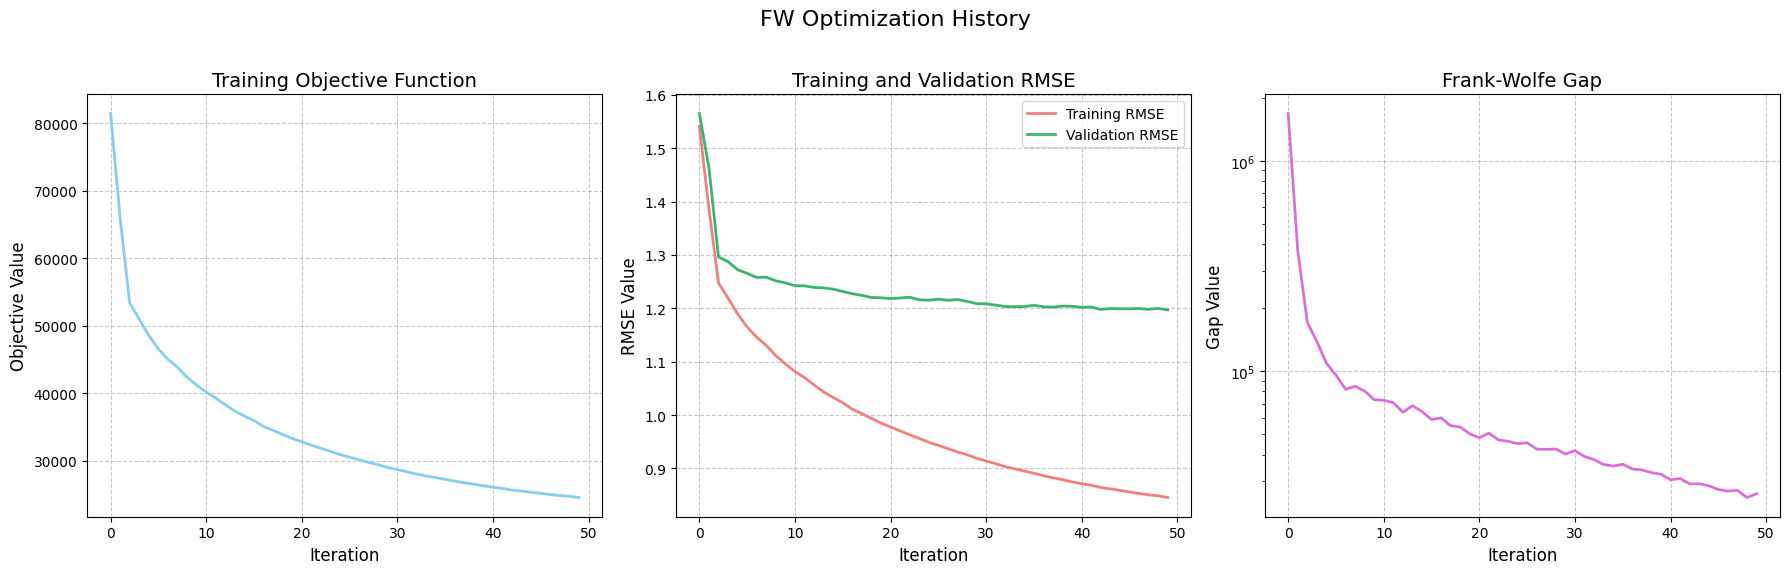

  FW Final: Test RMSE=1.1970, Rank=37, Time=1.00s

Running final PFW model...
Starting Pairwise Frank-Wolfe Optimization...


PFW Hash Progress:   0%|          | 0/50 [00:00<?, ?it/s]

[  0] Train RMSE: 3.6594 | Val RMSE: 3.6568 | Loss: 459393.0000 | Gap: 1118615.1250 | PGap: 1118615.1250 | StepSize: 0.6757 (chosen), 1.0000 (max) | ActiveSetSize: 1 | Rank 1; Nuclear norm 675.6895
...Optimization finished.


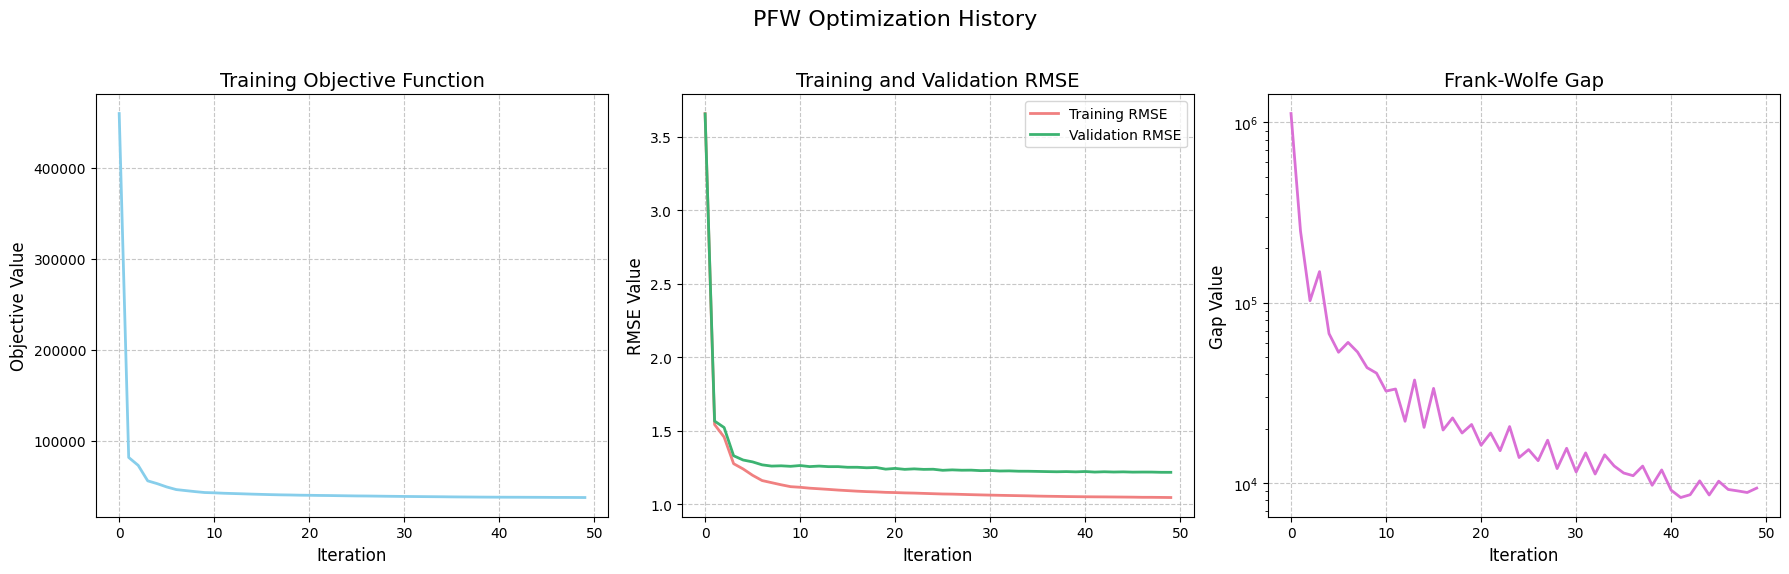

  PFW Final: Test RMSE=1.2145, Rank=22, Time=1.14s


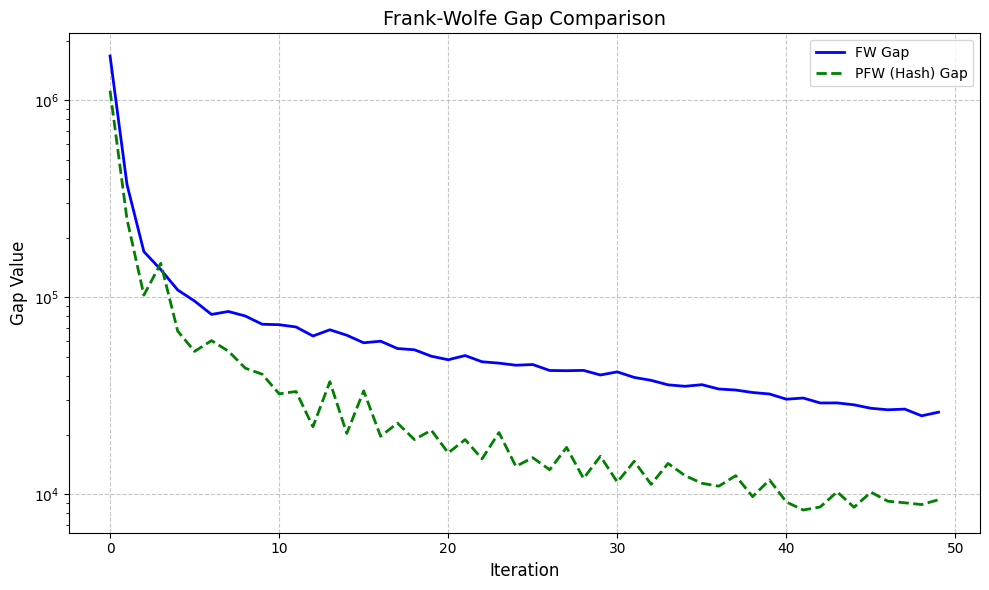


Running final PGD model...


PGD Progress:   0%|          | 0/50 [00:00<?, ?it/s]

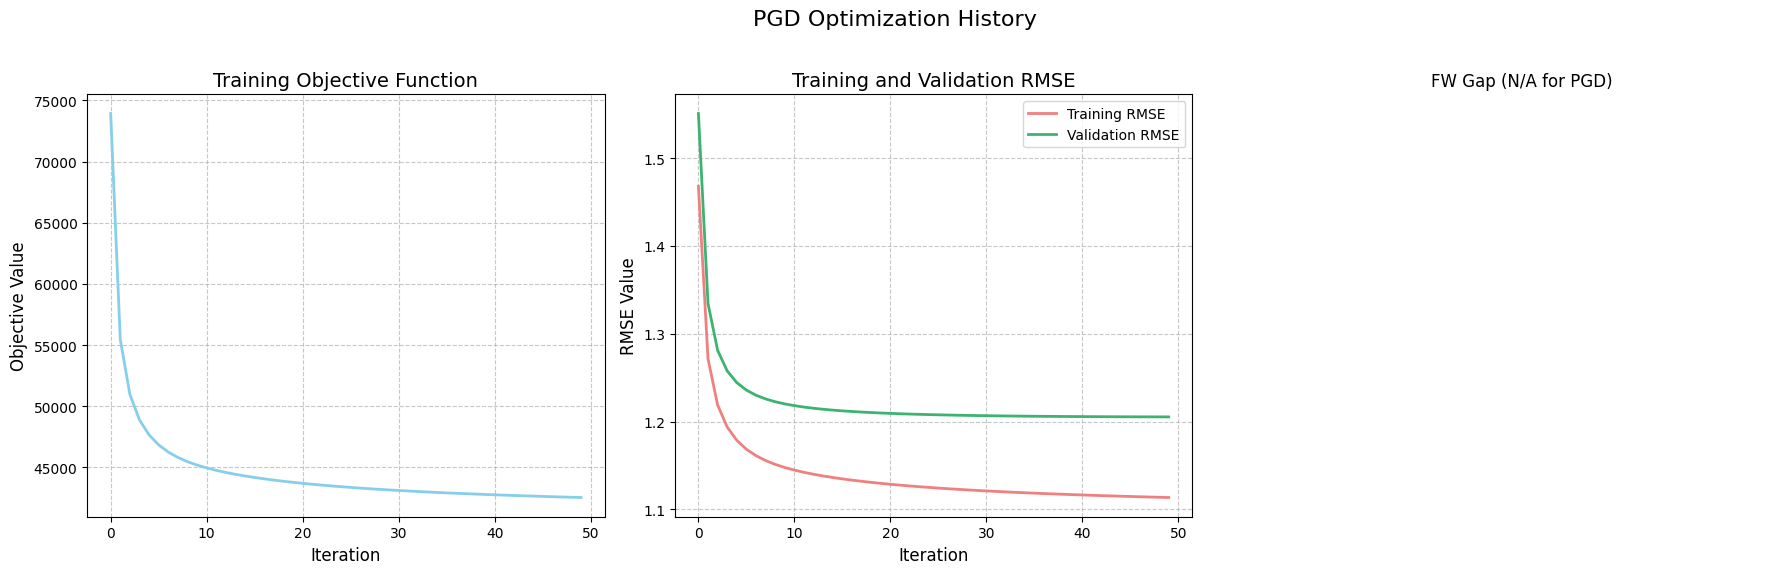

  PGD Final: Test RMSE=1.2053, Rank=2, Time=0.88s

--- Generating Plots ---


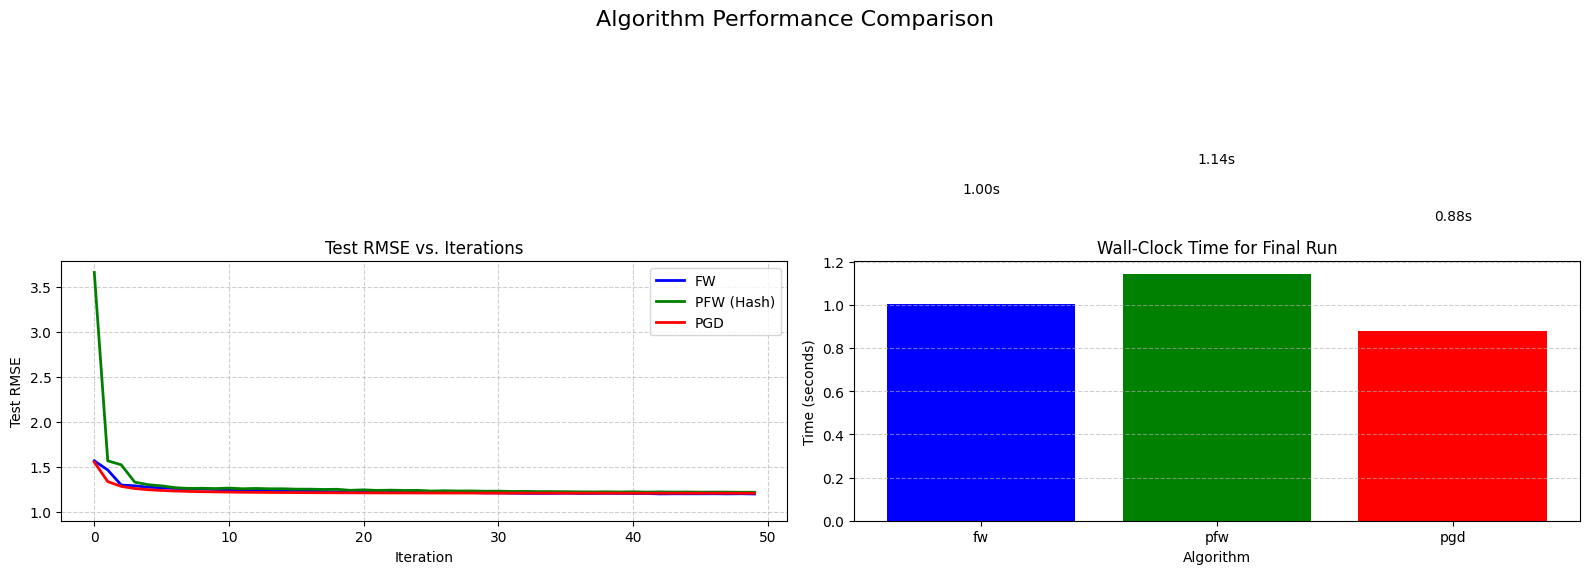

In [12]:
delta_search_space = [1000, 1500, 2000, 2500, 300]
lr_search_space = [0.001, 0.1, 0.5]
k_search_space = [2, 3, 5, 7]

final_results_sweets = run_pipeline(
  dataset="sweets",
  delta_list=delta_search_space,
  lr_list=lr_search_space,
  k_list=k_search_space,
  tune_iters=10,
  final_iters=50,
)

Extracting dataset...
Dataset extracted to ml-100k
Matrix nuclear norm: 21976.89453125
Matrix rank: 943
Split train/val/test: 70000/20000/10000
U shape: (943, 1682)
--- Starting Hyperparameter Tuning ---

Tuning Frank-Wolfe (FW)...
  Trying delta = 1500


FW Progress:   0%|          | 0/10 [00:00<?, ?it/s]

[  0] Train RMSE: 2.4753 | Val RMSE: 2.4921 | Loss: 428883.6875 | Gap: 1349340.0000 | StepSize: 0.7891 | Rank 1; Nuclear norm 1183.6061
  Trying delta = 2000


FW Progress:   0%|          | 0/10 [00:00<?, ?it/s]

[  0] Train RMSE: 2.4753 | Val RMSE: 2.4921 | Loss: 428883.6875 | Gap: 1799119.7500 | StepSize: 0.5918 | Rank 1; Nuclear norm 1183.6058
  Trying delta = 2500


...

  Trying lr = 1, k = 7


PGD Progress:   0%|          | 0/10 [00:00<?, ?it/s]

  => Best PGD params: lr=1, k=7 (Val RMSE: 1.2276)

--- Starting Final Training with Best Hyperparameters ---

Running final FW model...


FW Progress:   0%|          | 0/50 [00:00<?, ?it/s]

[  0] Train RMSE: 2.4767 | Val RMSE: 2.4953 | Loss: 552081.5000 | Gap: 4622735.5000 | StepSize: 0.2956 | Rank 1; Nuclear norm 1182.2565


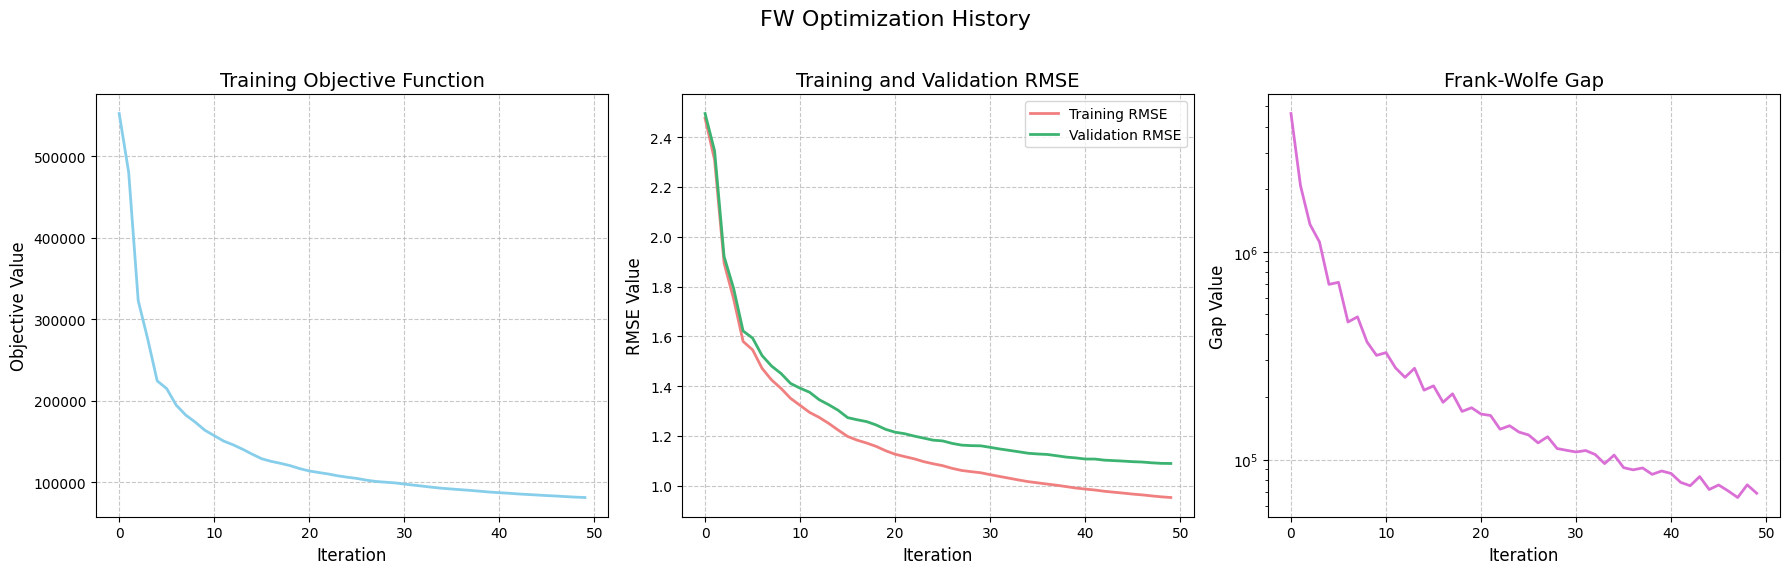

  FW Final: Test RMSE=1.0887, Rank=42, Time=1.28s

Running final PFW model...
Starting Pairwise Frank-Wolfe Optimization...


PFW Hash Progress:   0%|          | 0/50 [00:00<?, ?it/s]

[  0] Train RMSE: 3.7047 | Val RMSE: 3.7077 | Loss: 1235236.0000 | Gap: 4044893.5000 | PGap: 4044893.5000 | StepSize: 0.3378 (chosen), 1.0000 (max) | ActiveSetSize: 1 | Rank 1; Nuclear norm 1182.2563
...Optimization finished.


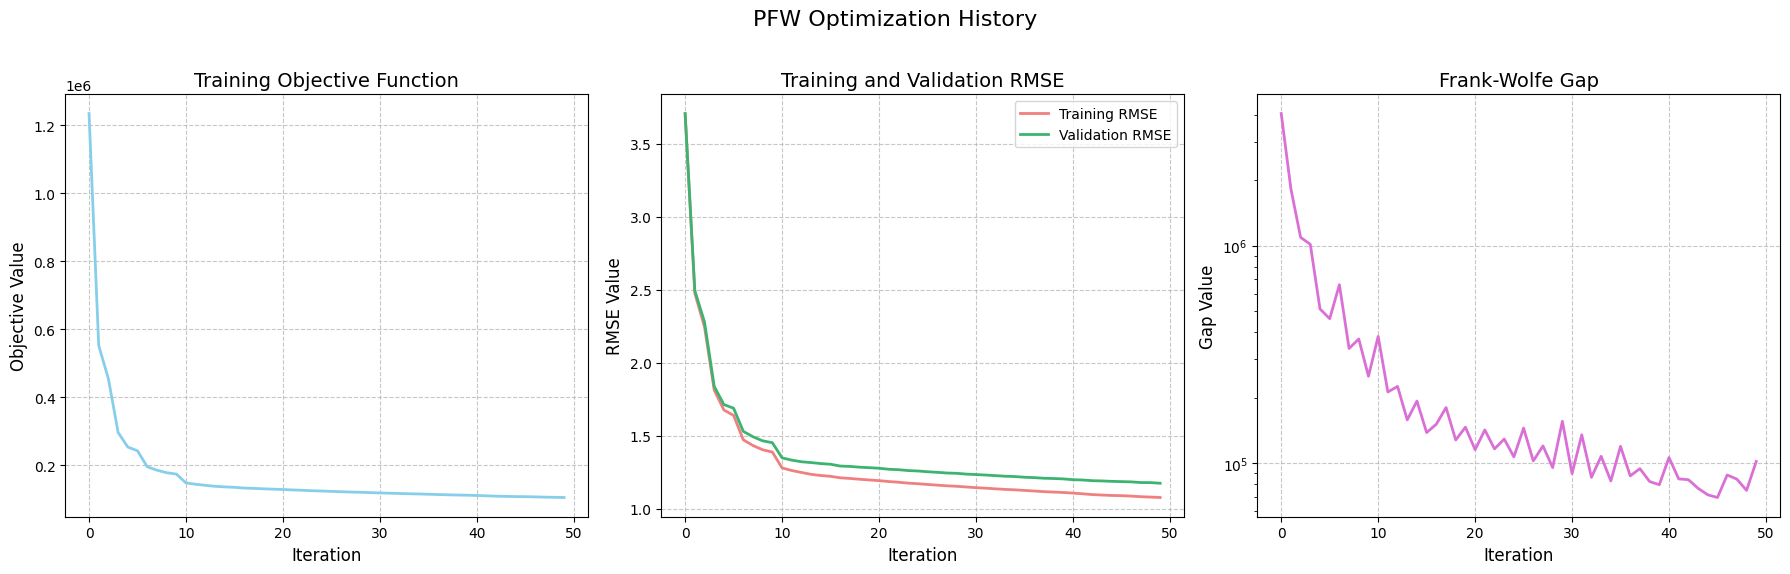

  PFW Final: Test RMSE=1.1739, Rank=23, Time=1.63s


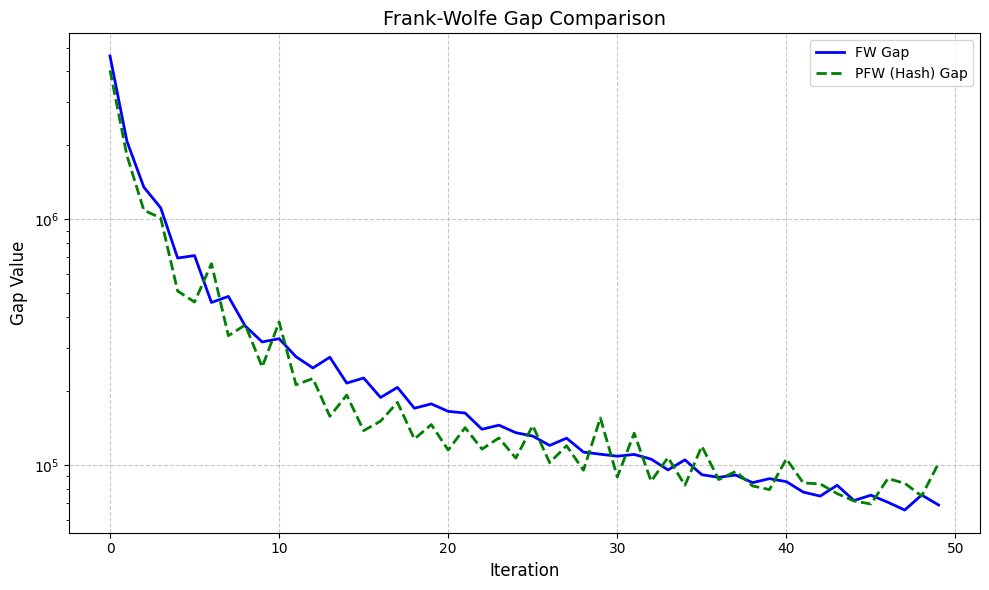


Running final PGD model...


PGD Progress:   0%|          | 0/50 [00:00<?, ?it/s]

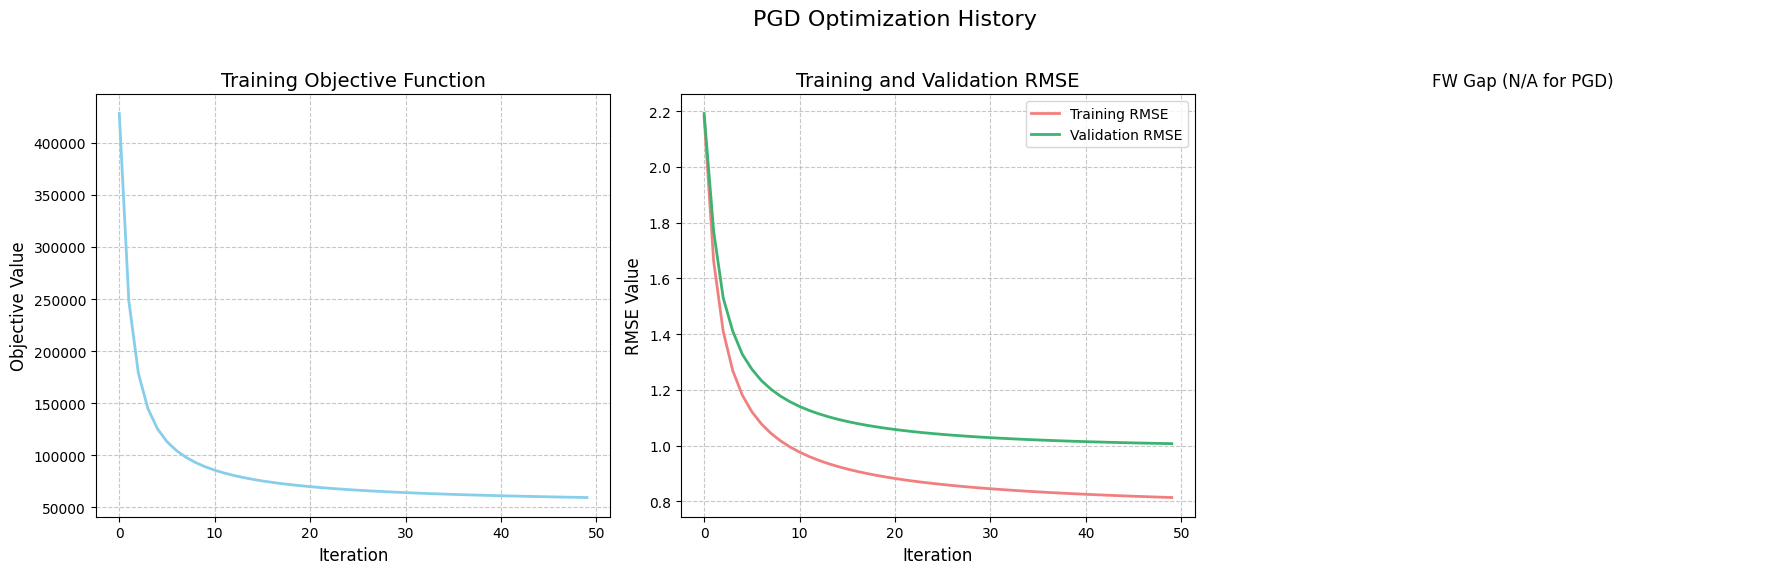

  PGD Final: Test RMSE=1.0068, Rank=7, Time=7.08s

--- Generating Plots ---


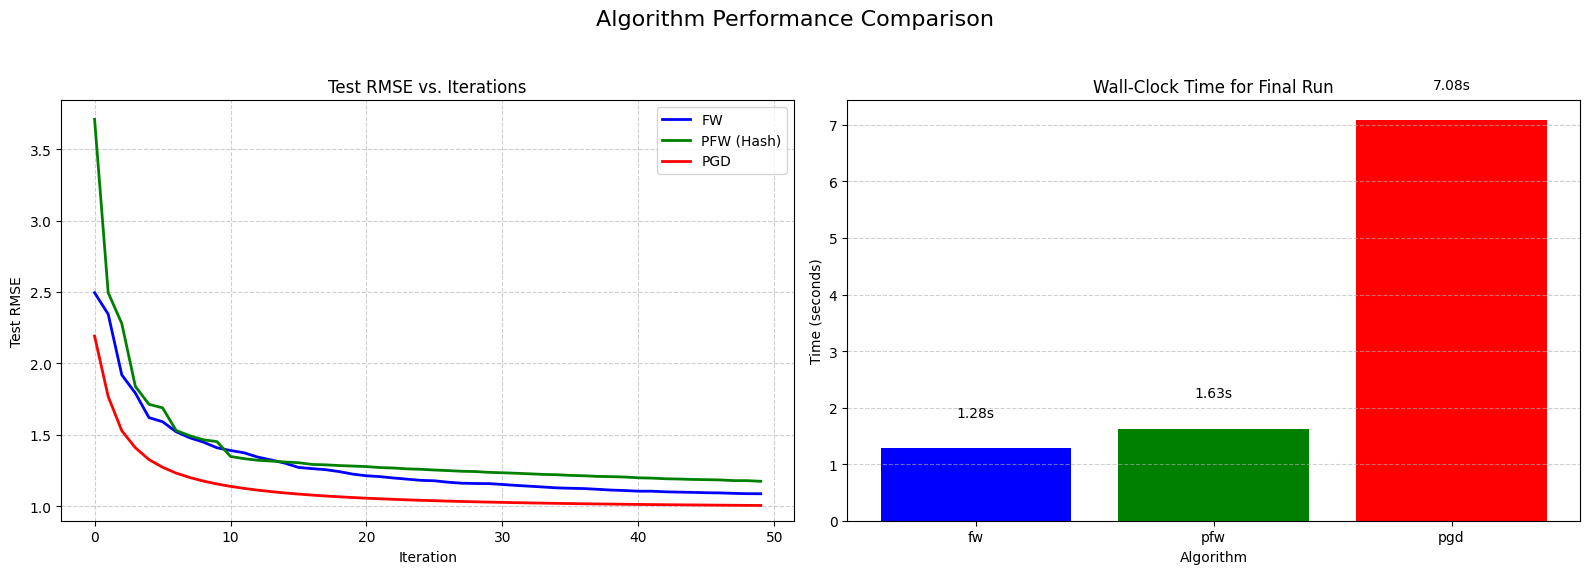

In [13]:
delta_search_space = [1500, 2000, 2500, 3500, 4000]
lr_search_space = [0.001, 0.1, 1]
k_search_space = [2, 3, 5, 7]

final_results_movielens = run_pipeline(
  dataset="movielens",
  delta_list=delta_search_space,
  lr_list=lr_search_space,
  k_list=k_search_space,
  tune_iters=10,
  final_iters=50,
)

Extracting dataset...
Dataset extracted to amazon_office
Matrix nuclear norm: 8586.291015625
Matrix rank: 966
Split train/val/test: 4319/1233/616
U shape: (1000, 1600)
--- Starting Hyperparameter Tuning ---

Tuning Frank-Wolfe (FW)...
  Trying delta = 1500


FW Progress:   0%|          | 0/5 [00:00<?, ?it/s]

[  0] Train RMSE: 4.1065 | Val RMSE: 4.1739 | Loss: 72832.3594 | Gap: 151933.3438 | StepSize: 0.1912 | Rank 1; Nuclear norm 286.8562
  Trying delta = 2000


FW Progress:   0%|          | 0/5 [00:00<?, ?it/s]

[  0] Train RMSE: 4.1065 | Val RMSE: 4.1739 | Loss: 72832.3594 | Gap: 202577.7812 | StepSize: 0.1434 | Rank 1; Nuclear norm 286.8562
  Trying delta = 2500


...

  Trying lr = 0.5, k = 7


PGD Progress:   0%|          | 0/5 [00:00<?, ?it/s]

  => Best PGD params: lr=0.5, k=2 (Val RMSE: 4.2049)

--- Starting Final Training with Best Hyperparameters ---

Running final FW model...


FW Progress:   0%|          | 0/10 [00:00<?, ?it/s]

[  0] Train RMSE: 4.0702 | Val RMSE: 4.1437 | Loss: 91977.7891 | Gap: 505557.4062 | StepSize: 0.0811 | Rank 1; Nuclear norm 324.5252


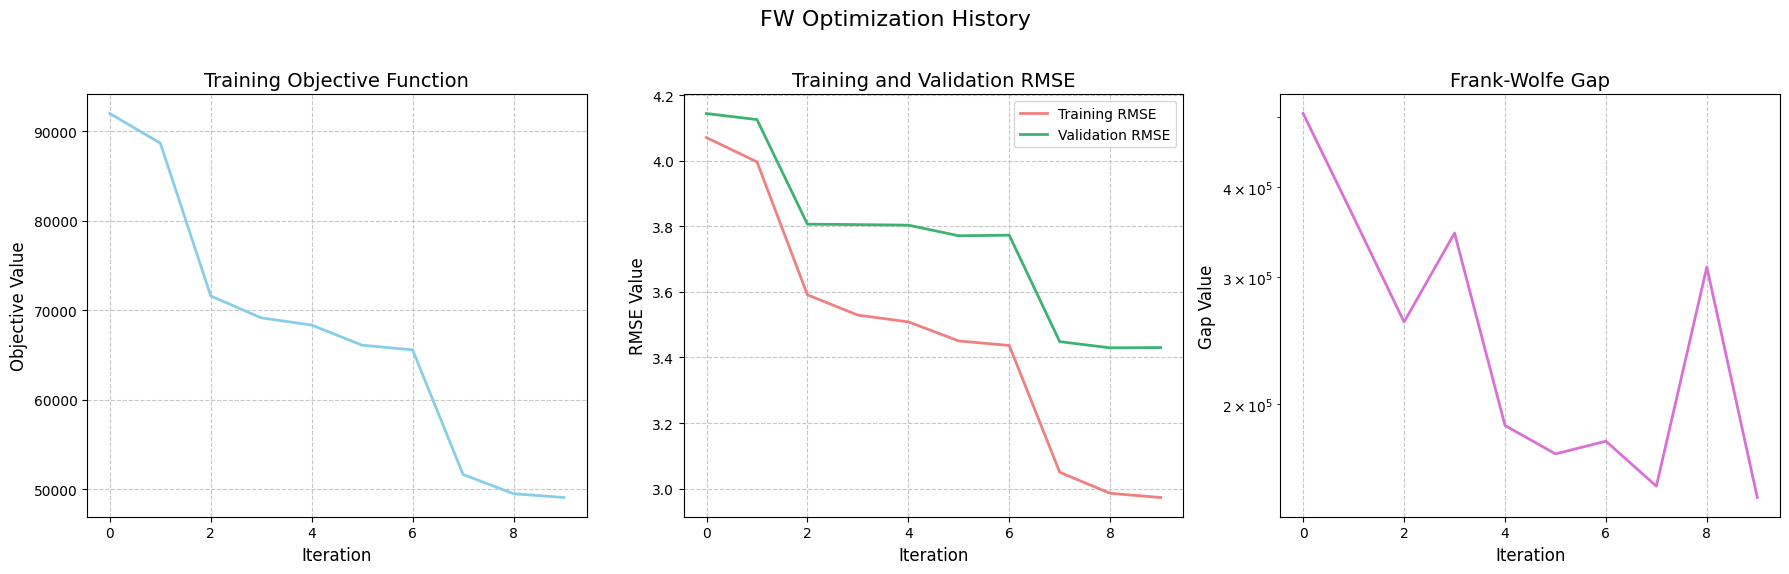

  FW Final: Test RMSE=3.4293, Rank=9, Time=1.13s

Running final PFW model...
Starting Pairwise Frank-Wolfe Optimization...


PFW Hash Progress:   0%|          | 0/10 [00:00<?, ?it/s]

[  0] Train RMSE: 4.5012 | Val RMSE: 4.5205 | Loss: 112486.0000 | Gap: 442362.7500 | PGap: 442362.7500 | StepSize: 0.0927 (chosen), 1.0000 (max) | ActiveSetSize: 1 | Rank 1; Nuclear norm 324.5252
...Optimization finished.


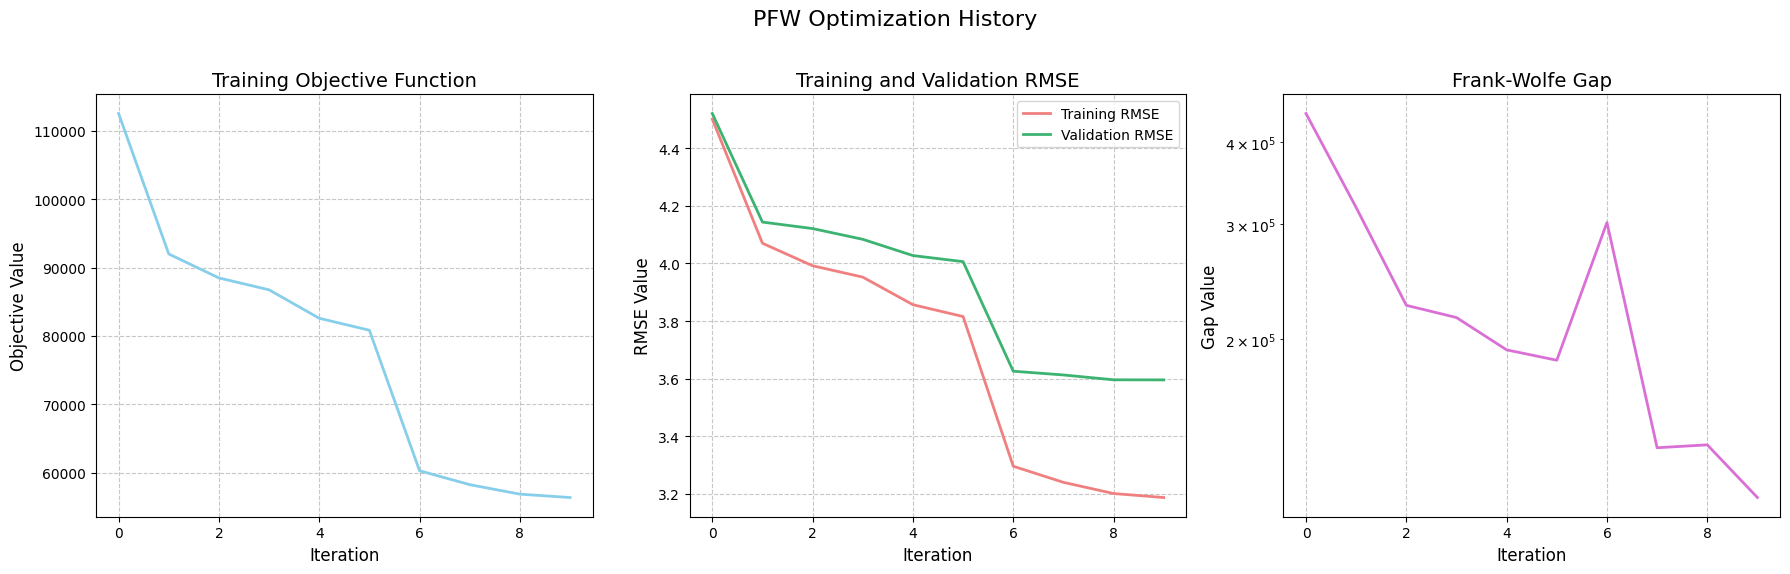

  PFW Final: Test RMSE=3.4480, Rank=8, Time=0.51s


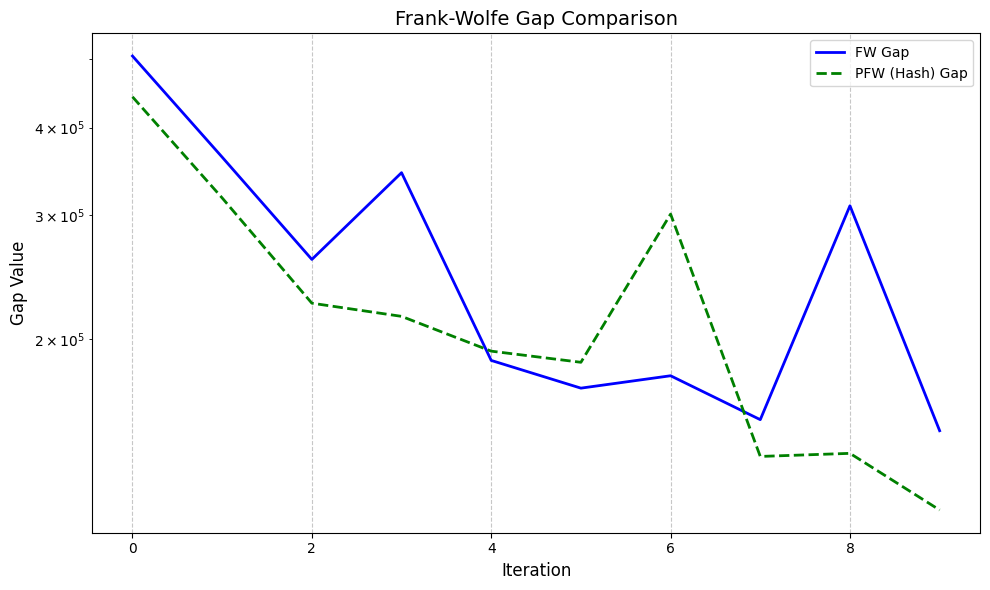


Running final PGD model...


PGD Progress:   0%|          | 0/10 [00:00<?, ?it/s]

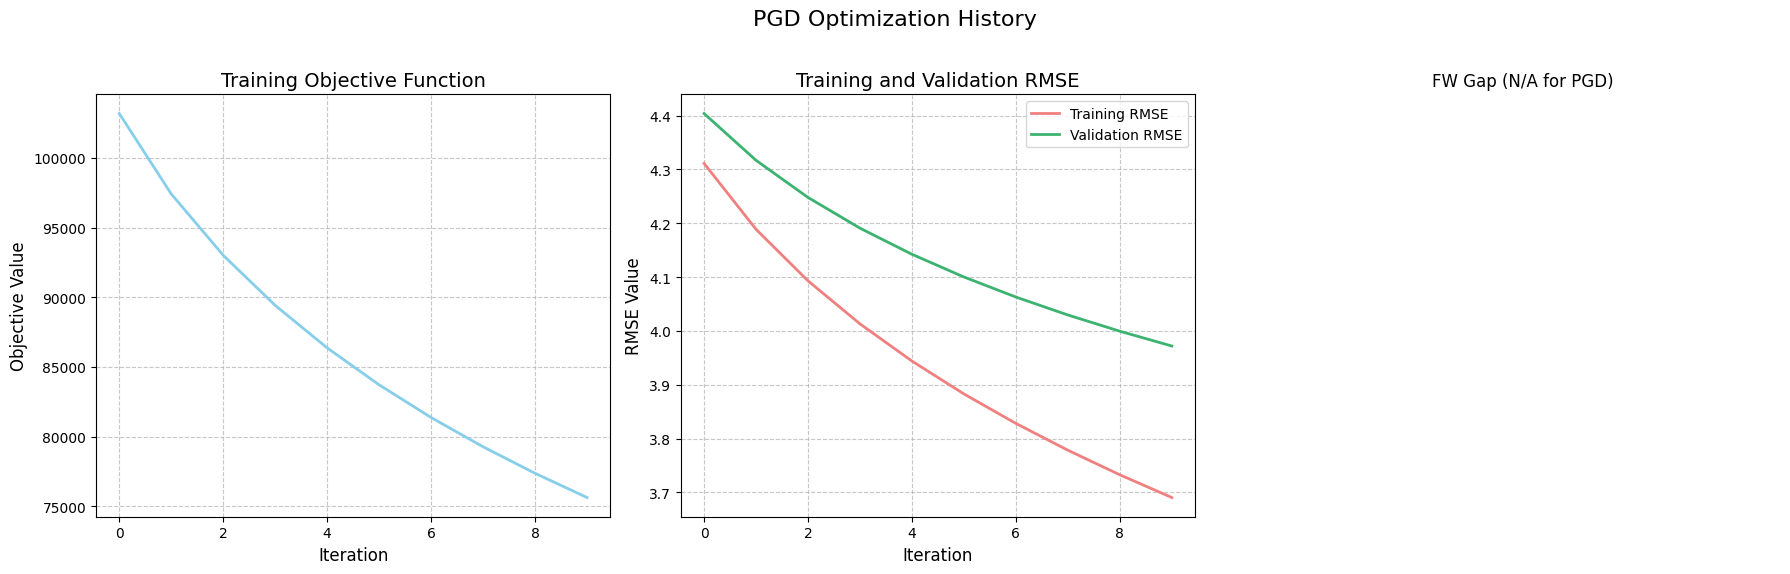

  PGD Final: Test RMSE=3.9720, Rank=2, Time=1.64s

--- Generating Plots ---


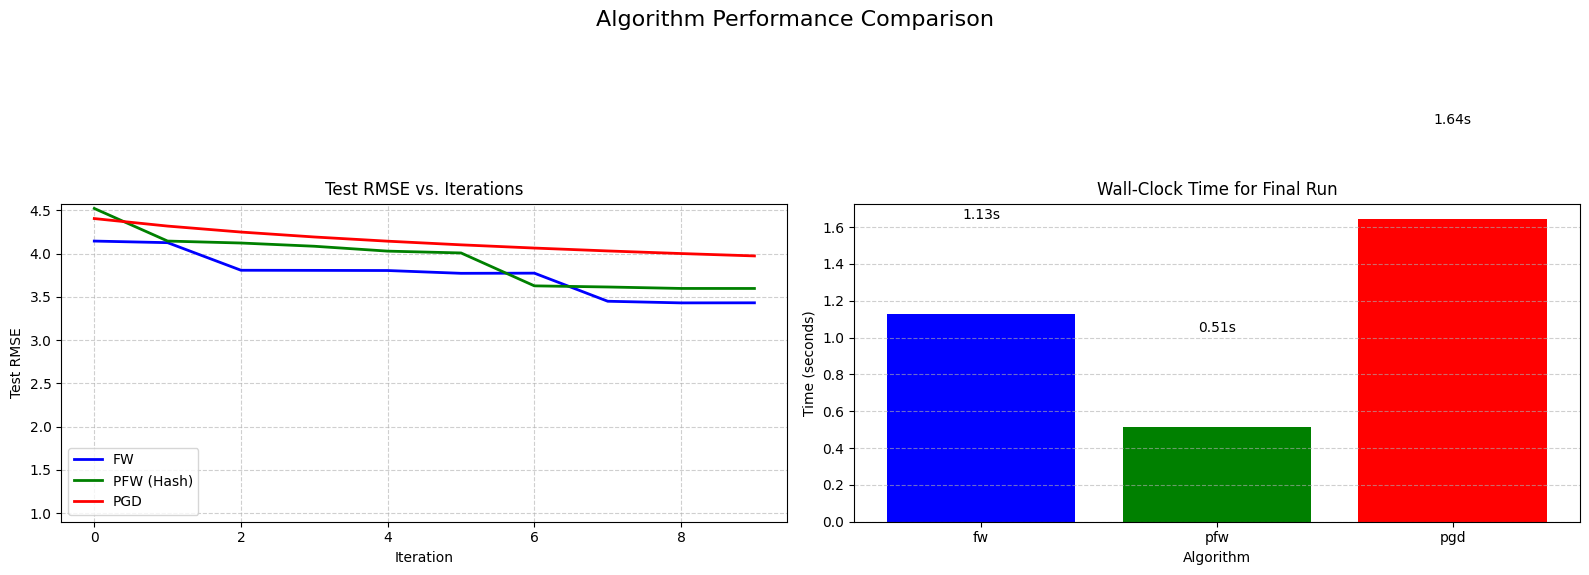

In [14]:
delta_search_space = [1500, 2000, 2500, 3500, 4000]
lr_search_space = [0.1, 0.5]
k_search_space = [2, 3, 5, 7]

final_results_amazon_office = run_pipeline(
  dataset="office",
  delta_list=delta_search_space,
  lr_list=lr_search_space,
  k_list=k_search_space,
  tune_iters=5,
  final_iters=10,
)

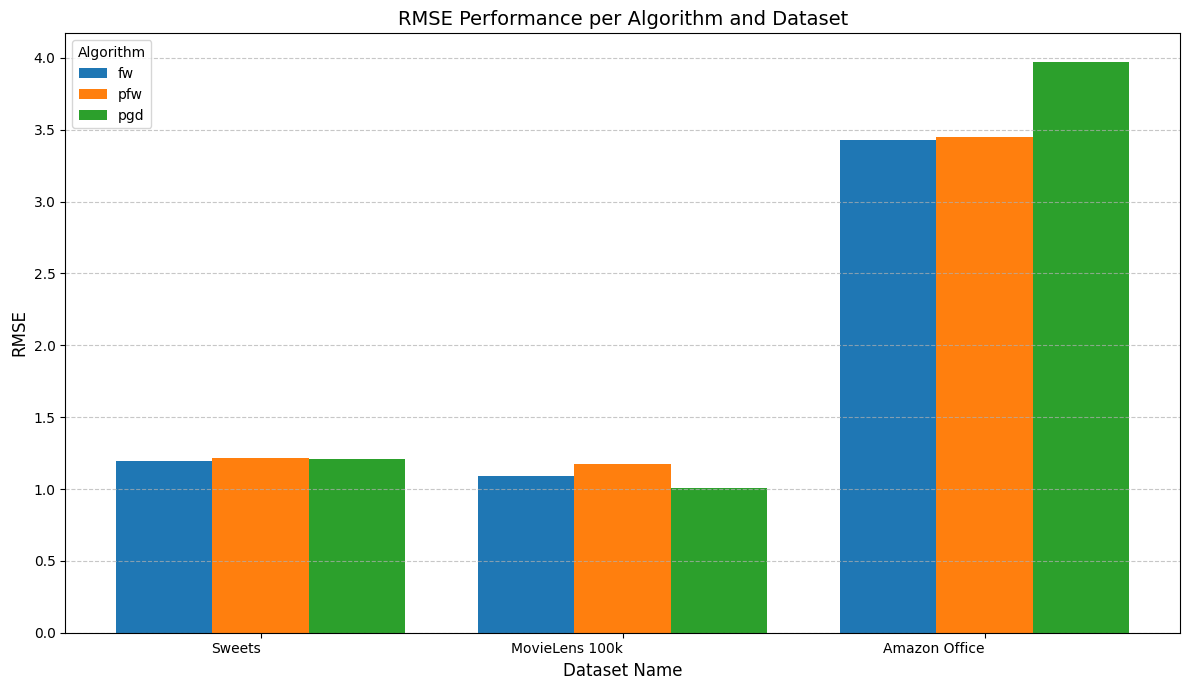

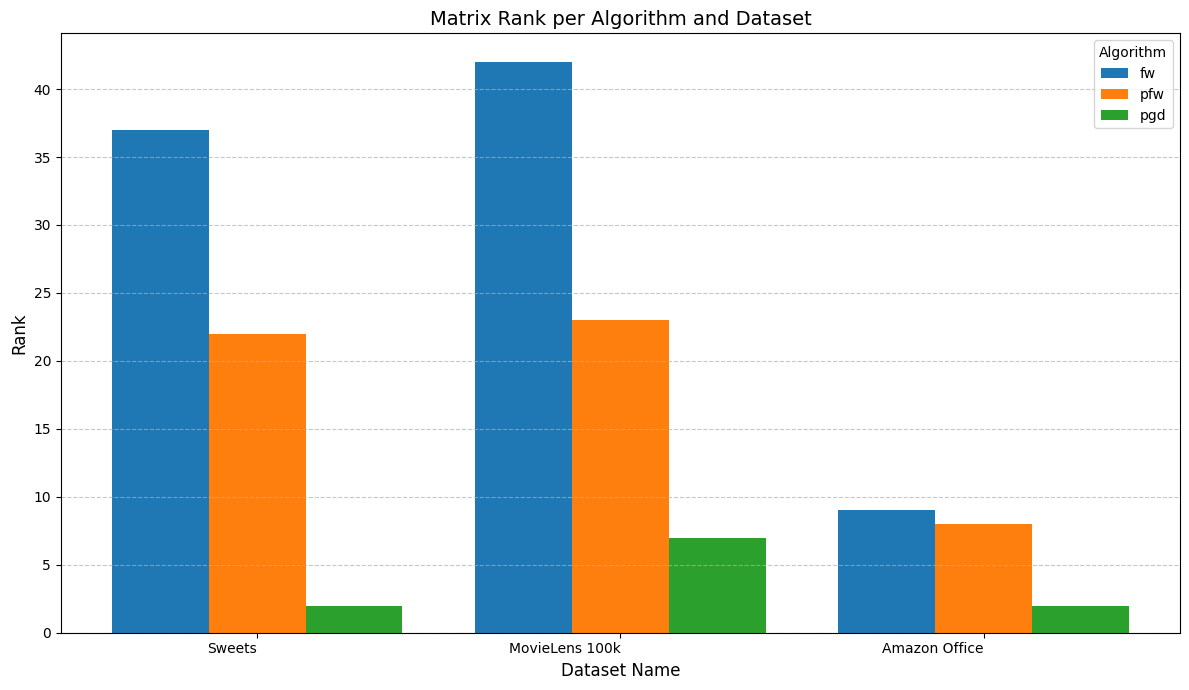

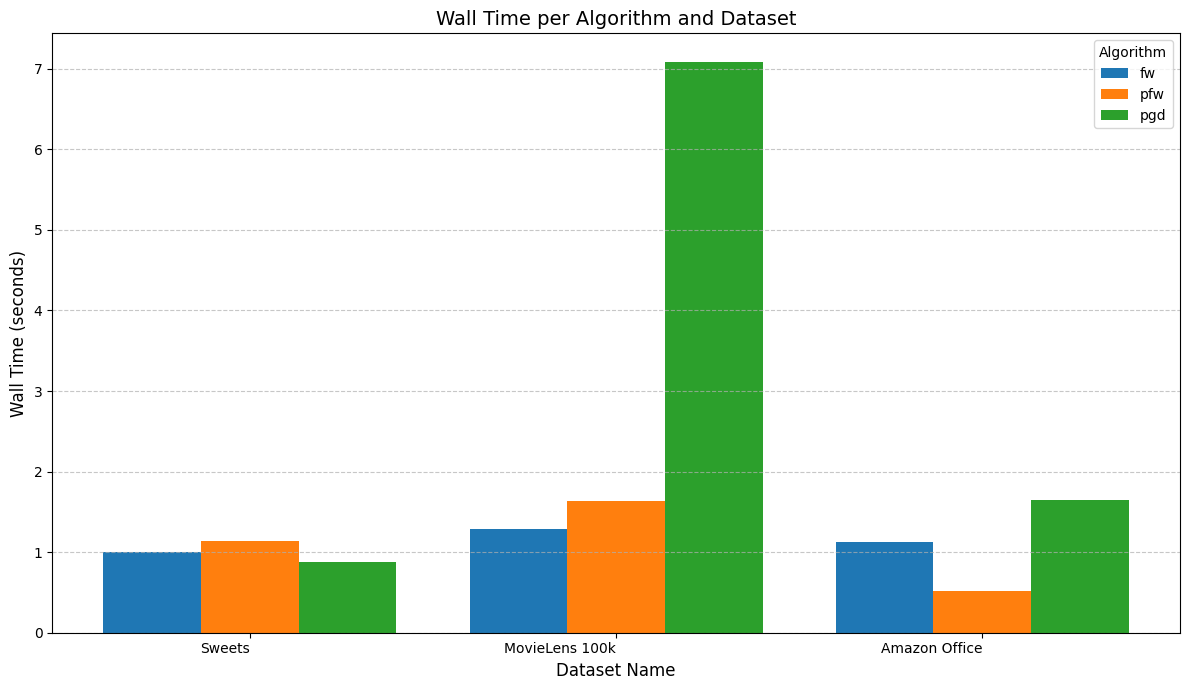

In [15]:
plot_algo_performance({
    'Sweets': final_results_sweets,
    'MovieLens 100k': final_results_movielens,
    'Amazon Office': final_results_amazon_office
})

## Plots about constraint effects on the rank and RMSE

MovieLens 100k dataset found.
Evaluating FW algorithm across 5 delta values...
Running delta 2000 (1/5)...
  Running FW for delta 2000...


FW Progress:   0%|          | 0/10 [00:00<?, ?it/s]

[  0] Train RMSE: 2.4751 | Val RMSE: 2.4974 | Loss: 490088.0000 | Gap: 2055339.2500 | StepSize: 0.5914 | Rank 1; Nuclear norm 1182.7058
    FW - Val RMSE: 1.6578, Test RMSE: 1.6578, Rank: 10
Running delta 3000 (2/5)...
  Running FW for delta 3000...


FW Progress:   0%|          | 0/10 [00:00<?, ?it/s]

[  0] Train RMSE: 2.4751 | Val RMSE: 2.4974 | Loss: 490088.0000 | Gap: 3083009.0000 | StepSize: 0.3942 | Rank 1; Nuclear norm 1182.7058
    FW - Val RMSE: 1.4609, Test RMSE: 1.4609, Rank: 10
Running delta 5000 (3/5)...
  Running FW for delta 5000...


...

[  0] Train RMSE: 2.4751 | Val RMSE: 2.4974 | Loss: 490088.0000 | Gap: 5138348.0000 | StepSize: 0.2365 | Rank 1; Nuclear norm 1182.7054
    FW - Val RMSE: 1.3985, Test RMSE: 1.3985, Rank: 10
Running delta 7000 (4/5)...
  Running FW for delta 7000...


FW Progress:   0%|          | 0/10 [00:00<?, ?it/s]

[  0] Train RMSE: 2.4751 | Val RMSE: 2.4974 | Loss: 490088.0000 | Gap: 7193687.0000 | StepSize: 0.1690 | Rank 1; Nuclear norm 1182.7054
    FW - Val RMSE: 1.3693, Test RMSE: 1.3693, Rank: 10
Running delta 10000 (5/5)...
  Running FW for delta 10000...


FW Progress:   0%|          | 0/10 [00:00<?, ?it/s]

[  0] Train RMSE: 2.4751 | Val RMSE: 2.4974 | Loss: 490088.0000 | Gap: 10276696.0000 | StepSize: 0.1183 | Rank 1; Nuclear norm 1182.7054
    FW - Val RMSE: 1.3528, Test RMSE: 1.3528, Rank: 10


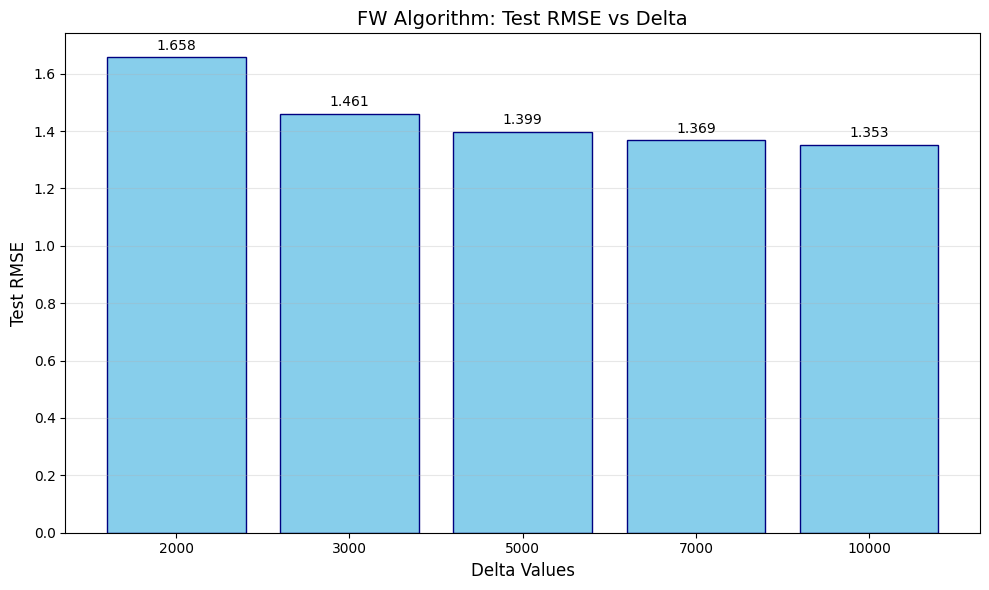

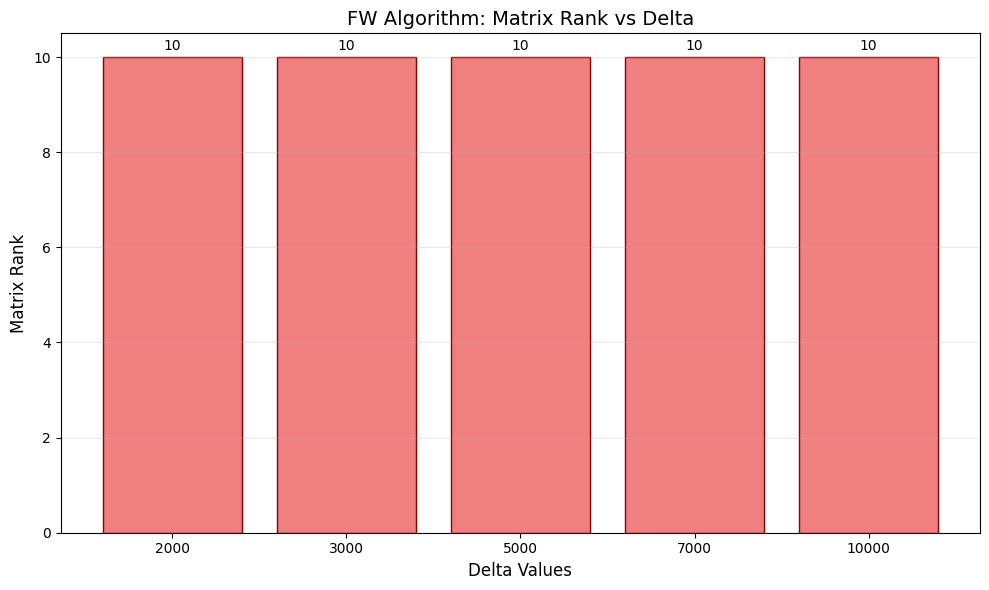


FW Results Summary:
--------------------------------------------------
Delta        Test RMSE    Rank    
--------------------------------------------------
2000         1.6578       10      
3000         1.4609       10      
5000         1.3985       10      
7000         1.3693       10      
10000        1.3528       10      


[{'delta': 2000,
  'val_rmse': Array(1.6577928, dtype=float32),
  'test_rmse': 1.6577928066253662,
  'rank': 10},
 {'delta': 3000,
  'val_rmse': Array(1.4608697, dtype=float32),
  'test_rmse': 1.4608696699142456,
  'rank': 10},
 {'delta': 5000,
  'val_rmse': Array(1.3985037, dtype=float32),
  'test_rmse': 1.3985036611557007,
  'rank': 10},
 {'delta': 7000,
  'val_rmse': Array(1.3692579, dtype=float32),
  'test_rmse': 1.369257926940918,
  'rank': 10},
 {'delta': 10000,
  'val_rmse': Array(1.3528079, dtype=float32),
  'test_rmse': 1.352807879447937,
  'rank': 10}]

In [17]:
def evaluate_deltas_and_plot_fw(deltas, max_iters, U, mask_train_original, mask_val_original, mask_test_original):
    """
    Evaluate the FW algorithm across different delta values and create bar charts.

    Args:
        deltas: list of delta values to test
        max_iters: int, maximum iterations for each run
        U: ground truth matrix
        mask_train_original: original training mask
        mask_val_original: original validation mask
        mask_test_original: original test mask
    """

    # Merge mask_train and mask_val, and use mask_test as validation
    mask_train_merged = mask_train_original | mask_val_original
    mask_val_for_fw = mask_test_original

    fw_results = []

    print(f"Evaluating FW algorithm across {len(deltas)} delta values...")

    for i, delta in enumerate(deltas):
        print(f"Running delta {delta} ({i+1}/{len(deltas)})...")

        # Run FW
        print(f"  Running FW for delta {delta}...")
        best_x_fw, best_val_rmse_fw, history_fw = fw(
            U=U,
            mask_train=mask_train_merged,
            mask_val=mask_val_for_fw,
            delta=delta,
            num_iters=max_iters,
        )
        test_rmse_fw = rmse(best_x_fw, U, mask_test_original)
        matrix_rank_fw = jnp.linalg.matrix_rank(best_x_fw)
        fw_results.append({
            'delta': delta,
            'val_rmse': best_val_rmse_fw,
            'test_rmse': float(test_rmse_fw),
            'rank': int(matrix_rank_fw)
        })
        print(f"    FW - Val RMSE: {best_val_rmse_fw:.4f}, Test RMSE: {test_rmse_fw:.4f}, Rank: {matrix_rank_fw}")

    # Extract data for plotting
    delta_values = [r['delta'] for r in fw_results]
    test_rmses_fw = [r['test_rmse'] for r in fw_results]
    ranks_fw = [r['rank'] for r in fw_results]

    x = jnp.arange(len(delta_values))  # the label locations
    width = 0.8  # the width of the bars for single plots

    # Create first plot: Delta vs Test RMSE
    fig1, ax1 = plt.subplots(figsize=(10, 6))
    bars_fw_rmse = ax1.bar(x, test_rmses_fw, width, label='FW Test RMSE', color='skyblue', edgecolor='navy')

    ax1.set_xlabel('Delta Values', fontsize=12)
    ax1.set_ylabel('Test RMSE', fontsize=12)
    ax1.set_title('FW Algorithm: Test RMSE vs Delta', fontsize=14)
    ax1.set_xticks(x)
    # Display delta values as integers (assuming they are whole numbers)
    ax1.set_xticklabels([str(int(d)) for d in delta_values])
    ax1.grid(axis='y', alpha=0.3)

    # Add value labels on bars
    for bar in bars_fw_rmse:
        height = bar.get_height()
        ax1.annotate(f'{height:.3f}',
                     xy=(bar.get_x() + bar.get_width() / 2, height),
                     xytext=(0, 3),  # 3 points vertical offset
                     textcoords="offset points",
                     ha='center', va='bottom', fontsize=10)
    plt.tight_layout()
    plt.savefig('fw_rmse_vs_delta.png')
    plt.show()

    # Create second plot: Delta vs Rank
    fig2, ax2 = plt.subplots(figsize=(10, 6))
    bars_fw_rank = ax2.bar(x, ranks_fw, width, label='FW Rank', color='lightcoral', edgecolor='darkred')

    ax2.set_xlabel('Delta Values', fontsize=12)
    ax2.set_ylabel('Matrix Rank', fontsize=12)
    ax2.set_title('FW Algorithm: Matrix Rank vs Delta', fontsize=14)
    ax2.set_xticks(x)
    # Display delta values as integers (assuming they are whole numbers)
    ax2.set_xticklabels([str(int(d)) for d in delta_values])
    ax2.grid(axis='y', alpha=0.3)

    # Add value labels on bars
    for bar in bars_fw_rank:
        height = bar.get_height()
        ax2.annotate(f'{int(height)}',
                     xy=(bar.get_x() + bar.get_width() / 2, height),
                     xytext=(0, 3),  # 3 points vertical offset
                     textcoords="offset points",
                     ha='center', va='bottom', fontsize=10)
    plt.tight_layout()
    plt.savefig('fw_rank_vs_delta.png')
    plt.show()

    # Print summary table
    print("\nFW Results Summary:")
    print("-" * 50)
    print(f"{'Delta':<12} {'Test RMSE':<12} {'Rank':<8}")
    print("-" * 50)
    for r in fw_results:
        # Display delta values as integers in the summary
        print(f"{int(r['delta']):<12} {r['test_rmse']:<12.4f} {r['rank']:<8}")

    return fw_results

deltas_to_test = [2000, 3000, 5000, 7000, 10000]

U, mask_train, mask_val, mask_test = load_movielens_100k(test_ratio = 0.2)

evaluate_deltas_and_plot_fw(
    deltas=deltas_to_test,
    max_iters=10,
    U=U,
    mask_train_original=mask_train,
    mask_val_original=mask_val,
    mask_test_original=mask_test
)

## Details about the dataset

In [19]:
def dataset_details(dataset_name):
    """
    Given a dataset name, return detailed statistics including:
    - Number of rows and columns (shape)
    - Density (observed entries over total entries)
    - Matrix rank and nuclear norm

    Args:
        dataset_name: Name of the dataset ('sweets', 'movielens', or 'amazon_office')
    """
    if dataset_name == "sweets":
        U, _, _, _ = load_sweetrs_dataset()
    elif dataset_name == "movielens":
        U, _, _, _ = load_movielens_100k()
    elif dataset_name == "amazon_office":
        U, _, _, _ = load_amazon_office()
    else:
        raise ValueError(f"Dataset {dataset_name} not found")

    print(f"Dataset: {dataset_name}")
    print(f"Shape: {U.shape}")
    print(f"Density: {jnp.sum(U != 0) / (U.size):.4f}")
    print(f"Rank: {jnp.linalg.matrix_rank(U)}")
    print(f"Nuclear norm: {jnp.linalg.norm(U, ord='nuc'):.2f}")


dataset_details("sweets")
dataset_details("movielens")
dataset_details("amazon_office")

SweetRS dataset found.
Dataset: sweets
Shape: (1476, 77)
Density: 0.3354
Rank: 77
Nuclear norm: 3321.29
MovieLens 100k dataset found.
Dataset: movielens
Shape: (943, 1682)
Density: 0.0630
Rank: 943
Nuclear norm: 21976.89
Amazon Office dataset found.
Dataset: amazon_office
Shape: (1000, 1600)
Density: 0.0039
Rank: 966
Nuclear norm: 8586.29
